In [5]:
from datetime import datetime
from enum import Enum
from numpy import sign
from pandas import DataFrame, Series
from plotly.graph_objs import Data
from pyparsing import line
from scipy import stats
from scipy.optimize import minimize, differential_evolution
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sympy import O, deg
from types import FunctionType
from xgboost import XGBRegressor
from xgboost import train
import glob
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import os
import os.path as path
import pandas as pd
import pulp
import pwlf
import random
import scipy.optimize as optimize
import scipy.stats as stats


import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")

# from tools import utils as u, config as cfg, plotting as up, preprocessing as pp
%load_ext autoreload
%autoreload 2

from tools import utils as u, config as cfg, plotting as up, preprocessing as pp
import tools

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# CONFIG

DATA_BASE_PATH = f"../../Data/"
DATA_TESTING_PATH= f"{DATA_BASE_PATH}/PHM2025_test_data/"
DATA_TRAINING_PATH = f"{DATA_BASE_PATH}/PHM2025_training_data/"
DATA_VALIDATION_PATH = f"{DATA_BASE_PATH}/PHM2025_validation_data/"
def DATA_TEST_DATA(num):
    return f"{DATA_TESTING_PATH}/test_{num}.csv"
def DATA_VALIDATION_DATA(num):
    return f"{DATA_TESTING_PATH}/val_{num}.csv"
DATA_TRAINING_DATA = f"{DATA_TESTING_PATH}/training_data.csv"
PLOT_PATH = f"./img/"

In [6]:
SENSORS = tools.types.enums.SENSORS

def remove_outliers(df: pd.DataFrame, sensor_cols=None, threshold=3, method='zscore') -> pd.DataFrame:
    """
    Identifica e rimuove gli outliers dai sensori, impostandoli a NaN.
    Supporta metodi basati su Z-score, IQR e Isolation Forest.

    :param df: DataFrame di input.
    :param sensor_cols: Lista di sensori.
    :param threshold: Soglia per lo z-score (default 3) o moltiplicatore per IQR (default 1.5/3).
    :param method: 'zscore', 'iqr', o 'isoforest'.
    :return: DataFrame con outliers sostituiti da NaN.
    """
    df_out = df.copy()
    if sensor_cols is None:
        target_sensors = [s.value if hasattr(s, 'value') else s for s in u.SENSORS]
    else:
        target_sensors = [s.value if hasattr(s, 'value') else s for s in sensor_cols]
    target_sensors = [s for s in target_sensors if s in df_out.columns]
    if method == 'zscore':
        for sensor in target_sensors:
            # Calcolo z-score ignorando i NaN
            series = df_out[sensor]
            if series.dropna().empty: continue
            z_scores = np.abs(stats.zscore(series, nan_policy='omit'))
            df_out.loc[z_scores > threshold, sensor] = np.nan
    elif method == 'iqr':
        for sensor in target_sensors:
            Q1 = df_out[sensor].quantile(0.25)
            Q3 = df_out[sensor].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR
            df_out.loc[(df_out[sensor] < lower_bound) | (df_out[sensor] > upper_bound), sensor] = np.nan
    elif method == 'isoforest':
        for sensor in target_sensors:
            series_nonan = df_out[sensor].dropna()
            if series_nonan.empty: continue
            data = series_nonan.values.reshape(-1, 1)
            # Contamination 'auto' o basata sulla soglia se interpretata come percentuale
            iso = IsolationForest(contamination='auto', random_state=42)
            preds = iso.fit_predict(data)
            # preds == -1 sono gli outliers
            outlier_indices = series_nonan.index[preds == -1]
            df_out.loc[outlier_indices, sensor] = np.nan
    return df_out

def missingfill(df: pd.DataFrame, align_cols=['Snapshot', 'Cycles_Since_New'], align_alt=['Snapshot', 'Cycles'], sensor_cols=None) -> pd.DataFrame:
    """
    Riempie i valori mancanti (NaN) integrando i dati presenti negli altri motori.
    Strategia:
    1. Calcola la media della flotta (tutti i motori disponibili) per lo stesso (Snapshot, Ciclo).
    2. Riempie i NaN con questa media.
    3. Per i valori ancora mancanti (es. nessun dato nella flotta per quel punto), esegue interpolazione lineare per ESN.
    :param df: DataFrame contenente i dati.
    :param align_cols: Colonne usate per allineare i cicli tra motori.
    :param sensor_cols: Lista di sensori da processare. Se None, usa i SENSORS globali.
    :return: DataFrame con i missing values riempiti.
    """
    # 1. Determinazione colonne sensori
    if sensor_cols is None:
        # Usa i sensori globali definiti in questo modulo
        raw_sensors = list(SENSORS)
    else:
        raw_sensors = list(sensor_cols)
    # Risoluzione nomi sensori (se sono Enum)
    valid_cols = []
    for s in raw_sensors:
        s_name = s.value if hasattr(s, 'value') else str(s)
        if s_name in df.columns:
            valid_cols.append(s_name)
    if not valid_cols:
        print("Nessuna colonna sensore valida trovata per missingfill.")
        return df
    df_out = df.copy()
    print(f"Esecuzione missingfill su {len(valid_cols)} sensori...")
    # 2. Riempimento tramite Media Flotta (Fleet Mean)
    # Verifica che le colonne di allineamento esistano
    if all(col in df_out.columns for col in align_cols):
        try:
            # Calcola media raggruppata per align_cols sui sensori
            # transform('mean') restituisce un DF/Series allineato all'originale con le medie dei gruppi
            fleet_means = df_out.groupby(align_cols)[valid_cols].transform('mean')
            # Sostituzione dei NaN con la media calcolata
            df_out[valid_cols] = df_out[valid_cols].fillna(fleet_means)
        except Exception as e:
            print(f"Warning: Errore durante il calcolo della media flotta: {e}")
    else:
        fleet_means = df_out.groupby(align_alt)[valid_cols].transform('mean')
        # Sostituzione dei NaN con la media calcolata
        df_out[valid_cols] = df_out[valid_cols].fillna(fleet_means)
        # print(f"Warning: Colonne di allineamento {align_cols} non trovate. Salto step flotta.")
    # 3. Interpolazione Residua (Per ESN)
    # Se la media flotta non ha coperto tutto (es. cicli dove nessuno ha dati), eseguiamo forward fill
    if 'ESN' in df_out.columns:
        # Applica interpolazione per ogni sensore, raggruppando per ESN
        for col in valid_cols:
            # Interpolazione residua: Forward Fill come richiesto
            df_out[col] = df_out.groupby('ESN')[col].transform(lambda x: x.ffill())
            # Fallback: Backward Fill per coprire eventuali NaN all'inizio della serie
            df_out[col] = df_out.groupby('ESN')[col].transform(lambda x: x.bfill())
    return df_out



In [7]:
testing_esn = 102
operating_vars = ['Sensed_Altitude', 'Sensed_Mach', 'Sensed_Pamb', 'Sensed_TAT', 'Sensed_VAFN', 'Sensed_VBV', 'Sensed_Fan_Speed', 'Sensed_Pt2']
# degradation_vars = [s for s in u.SENSORS if s not in operating_vars] # scommentare se si vuole considerare anche i sensori non in test o valiation
degradation_vars = [s for s in SENSORS if s not in operating_vars and s != "Sensed_P25" and s != "Sensed_T5"]
managed_cols = set(degradation_vars) | set(operating_vars)

In [8]:
# other_cols_df = [col for col in df.columns if col not in managed_cols]
# agg_logic = {col: 'median' for col in degradation_vars}
# agg_logic.update({col: 'median' for col in operating_vars})
# agg_logic.update({col: 'first' for col in other_cols_df})

# DOWNSAMPLING TRAINING PER AVERE PER TUTTI LO STESSO NUMERO DI DATI
df = u.load_training()
df = pp.remove_outliers(df, SENSORS)
df = pp.missingfill(df).dropna()

# # Aggregazione dataset di training
# df = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_logic).reset_index(drop=True)
# rows = df.groupby('ESN').size().reset_index(name='rows').copy()
# print(rows)

# DOWNSAMPLING VALIDATION PER AVERE PER TUTTI LO STESSO NUMERO DI DATI
dfv = u.load_validation(range(0,48))
temp = []
for esn in dfv["ESN"].unique():
    temp.append(dfv[dfv["ESN"] == esn].reset_index())
dfv = pd.concat(temp)
dfv = pp.remove_outliers(dfv, SENSORS)
dfv = pp.missingfill(dfv, align_cols=["Snapshot", "Cycles"]).dropna()

# Aggregazione dataset di validation
# other_cols_dfv = [col for col in dfv.columns if col not in managed_cols]
# agg_logic_v = {col: 'median' for col in degradation_vars}
# agg_logic_v.update({col: 'median' for col in operating_vars})
# agg_logic_v.update({col: 'first' for col in other_cols_dfv})
# dfv = dfv.groupby(['ESN', 'Cycles']).agg(agg_logic_v).reset_index(drop=True)
# rows_val = dfv.groupby('ESN').size().reset_index(name='numero_righe').copy()
# print(rows_val)

# DOWNSAMPLING TESTING PER AVERE PER TUTTI LO STESSO NUMERO DI DATI
# dft = u.load_testing(range(0,52))
dft = u.load_testing(39)
temp = []
for esn in dft["ESN"].unique():
    temp.append(dft[dft["ESN"] == esn].reset_index())
dft = pd.concat(temp)
dft = pp.remove_outliers(dft, SENSORS)
dft = pp.missingfill(dft, align_cols=["Snapshot", "Cycles"]).dropna()
# Aggregazione dataset di training
# other_cols_dft = [col for col in dft.columns if col not in managed_cols]
# agg_logic_t = {col: 'median' for col in degradation_vars}
# agg_logic_t.update({col: 'median' for col in operating_vars})
# agg_logic_t.update({col: 'first' for col in other_cols_dft})
# dft = dft.groupby(['ESN', 'Cycles']).agg(agg_logic_t).reset_index(drop=True)
# rows_test = dft.groupby('ESN').size().reset_index(name='numero_righe').copy()

%store df
%store dfv
%store dft

# print(rows_test)

Esecuzione missingfill su 16 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Stored 'df' (DataFrame)
Stored 'dfv' (DataFrame)
Stored 'dft' (DataFrame)


In [ ]:
# FUNCTIONS
def train_models(df, operating_vars, degradation_vars) -> dict[int, dict[str,LinearRegression]]:
    X_train = df[operating_vars]
    Y_train = df[degradation_vars]
    models = {}
    for i in range(0,8):
        X_temp = pd.DataFrame(np.roll(X_train, i, axis=1))
        models[i] = {}
        models[i]["model"] = train_model(X_temp, Y_train)
    return models

def train_model(X_train, Y_train):
    model = LinearRegression()
    model.fit(X_train, Y_train)
    return model

def s_pred(s_o, model):
    return model.predict(s_o)

def residual(s_d, s_o, model):
    return s_d - s_pred(s_o, model)

def wind(y_p, y, a):
    diff = y - y_p
    num = np.where(diff >= 0, 2.0, 1.0)
    if isinstance(y_p, pd.DataFrame) or isinstance(y_p, pd.Series):
        y_p = y_p.values
    return num / (1 + a * y_p)

def TWE(y_p, y, a, b):
    if isinstance(y_p, pd.DataFrame): y_p = y_p.values
    weight = wind(y_p, y, a)
    squared_error = (y - y_p) ** 2
    return weight * squared_error * b

def HI(T3_res, T45_res, alpha):
    return -alpha * T3_res - T45_res

def minmax(df, column):
    col_min = df[column].min()
    col_max = df[column].max()
    return (df[column] - col_min) / (col_max - col_min)

def minmax_all(df):
    newdf = pd.DataFrame()
    for column in df.columns:
        col_min = df[column].min()
        col_max = df[column].max()
        newdf[column] = (df[column] - col_min) / (col_max - col_min)
    return newdf

def median_norm(df):
    for i in range(0,7):
        m = df.iloc[:,i].median()
        df.iloc[:,i] -= m
    return df

def objective(alpha, T3, T45, RUL):
    hi = -alpha*T3 - T45
    RUL = RUL.dropna()
    hi = hi.dropna()
    corr = stats.pearsonr(RUL,hi)
    # return np.sqrt(np.mean((hi - RUL)**2)) + 1
    return - corr[0]

def objective_beta(params, T3, T45, RUL):
    alpha, beta = params
    hi = -alpha*T3 - beta*T45
    RUL = RUL.dropna()
    hi = hi.dropna()
    corr = stats.pearsonr(RUL,hi)
    # return np.sqrt(np.mean((hi - RUL)**2)) + 1
    return - corr[0]

def HIE(params, vars):
    #return np.sum([-params[i]*vars.iloc[:,i] for i in range(0, 8)])
    return vars.dot(-np.array(params))


def objective_experimental(params, vars, RUL):
    hi = HIE(params, vars)
    # RUL = RUL.dropna()
    corr = stats.pearsonr(RUL,hi)
    return -corr[0]

def objective_deviation(params, vars, RUL):
    hi = HIE(params, vars)
    hi_min, hi_max = hi.min(), hi.max()
    if hi_max == hi_min:
        # Penalità se l'HI è una linea piatta
        return 1.0
    hi_norm = (hi - hi_min) / (hi_max - hi_min)
    mse = np.mean((hi_norm - RUL)**2)
    return mse

def get_rolling_slope_intercept(series, window):
    slopes = []
    intercepts = []
    series = np.asarray(series).flatten()
    for i in range(len(series)):
        if i < window:
            slopes.append(0)
            intercepts.append(0)
        else:
            y = series[i-window:i]
            x = np.arange(window)
            # Fit polinomiale di grado 1 (retta) -> ritorna [slope, intercept]
            poly = np.polyfit(x, y, 1)
            slopes.append(float(poly[0]))
            intercepts.append(float(poly[1]))
    return np.array(slopes), np.array(intercepts)


def normalize(col):
  col_min, col_max = col.min(), col.max()
  col = (col - col_min) / (col_max - col_min)
  col = col.to_frame()
  return col


def get_slope(y):
    """Calcola la pendenza della retta di regressione per una finestra y"""
    x = np.arange(len(y))
    # Polyfit di grado 1 restituisce [pendenza, intercetta]
    slope = np.polyfit(x, y, 1)[0]
    return slope

In [ ]:
print(df.columns)

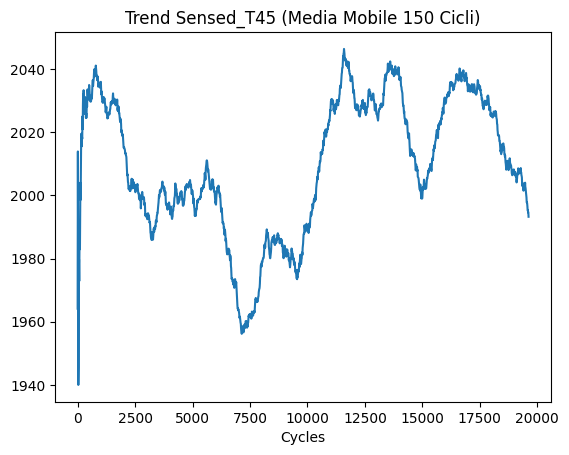

In [10]:
cycle_means = dfv.groupby(["ESN", "Cycles"])["Sensed_T45"].mean()
rolled = cycle_means.groupby(level="ESN").rolling(window=150, min_periods=1).mean()

rolled = rolled.droplevel(0) 

rolled.loc[108].plot(title="Trend Sensed_T45 (Media Mobile 150 Cicli)")
plt.show()

In [ ]:
# Regressore lineare per il calcolo dei residui

from tkinter import W


cycles_healthy = 20000

testing_esn = 102
val_data = df[df["ESN"] == testing_esn].reset_index().copy()
X_val = val_data[operating_vars]
Y_val = val_data[degradation_vars]

train_data_full = df[df["ESN"] != testing_esn].copy()
train_data_healthy = train_data_full.groupby("ESN").head(cycles_healthy).reset_index(drop=True)

base_df = train_data_healthy.copy()
new_synthetic_units = []
for i in range(400):
    aug_df = base_df.copy()
    noise = np.random.normal(loc=0, scale=10, size=aug_df[degradation_vars + operating_vars].shape)
    aug_df[degradation_vars + operating_vars] += noise
    aug_df['ESN'] = f"aug_{i}" 
    new_synthetic_units.append(aug_df)

train_data_healthy_augmented = pd.concat([train_data_healthy] + new_synthetic_units, ignore_index=True)

X_train = train_data_healthy_augmented[operating_vars]
Y_train = train_data_healthy_augmented[degradation_vars]

print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)

# training regressore lineare
model = train_model(X_train, Y_train)
%store model


# predict dei valori
res_list = []
for esn in train_data_full["ESN"].unique():
  mask = train_data_full["ESN"] == esn
  X_train = train_data_full.loc[mask, operating_vars]
  Y_train = train_data_full.loc[mask, degradation_vars]
  Y_pred = model.predict(X_train)
  plt.figure()
  plt.plot(Y_train)
  plt.show()
  res_temp = Y_train - Y_pred
  res_temp["Cycles_Since_New"] = train_data_full[mask]["Cycles_Since_New"]
  res_temp["Snapshot"] = train_data_full[mask]["Snapshot"]
  res_temp["ESN"] = esn
  res_list.append(res_temp)

res_train = pd.concat(res_list)



# residui
res_val_list = []
Y_pred = model.predict(X_val)
res_val_temp = Y_val - Y_pred
res_val_list.append(res_val_temp)
res_val = pd.concat(res_val_list)

plt.plot(res_val)
plt.show()

# integrazione residui sul dataset originale
cleaned_chunks = []
for esn in train_data_full["ESN"].unique():
  temp = res_train[res_train["ESN"] == esn].copy()
  temp = remove_outliers(temp, SENSORS, threshold=0.8)
  temp[degradation_vars] = temp[degradation_vars].rolling(window=15, min_periods=1).median()
  temp = temp.dropna()
  cleaned_chunks.append(temp)

res_train = pd.concat(cleaned_chunks).dropna()

for esn in res_train.ESN.unique():
  plt.figure(figsize=(10,30))
  for i,d in enumerate(degradation_vars):
    for snap in range(1,9):
      plt.subplot(8,1,i+1)
      plt.plot(res_train[(res_train["ESN"] == esn) & (res_train["Snapshot"] == snap)][d], label=d, linewidth=0.4)
      plt.legend()
  plt.show()

train_data_full.update(res_train)



/tmp/ipykernel_13948/1734958586.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


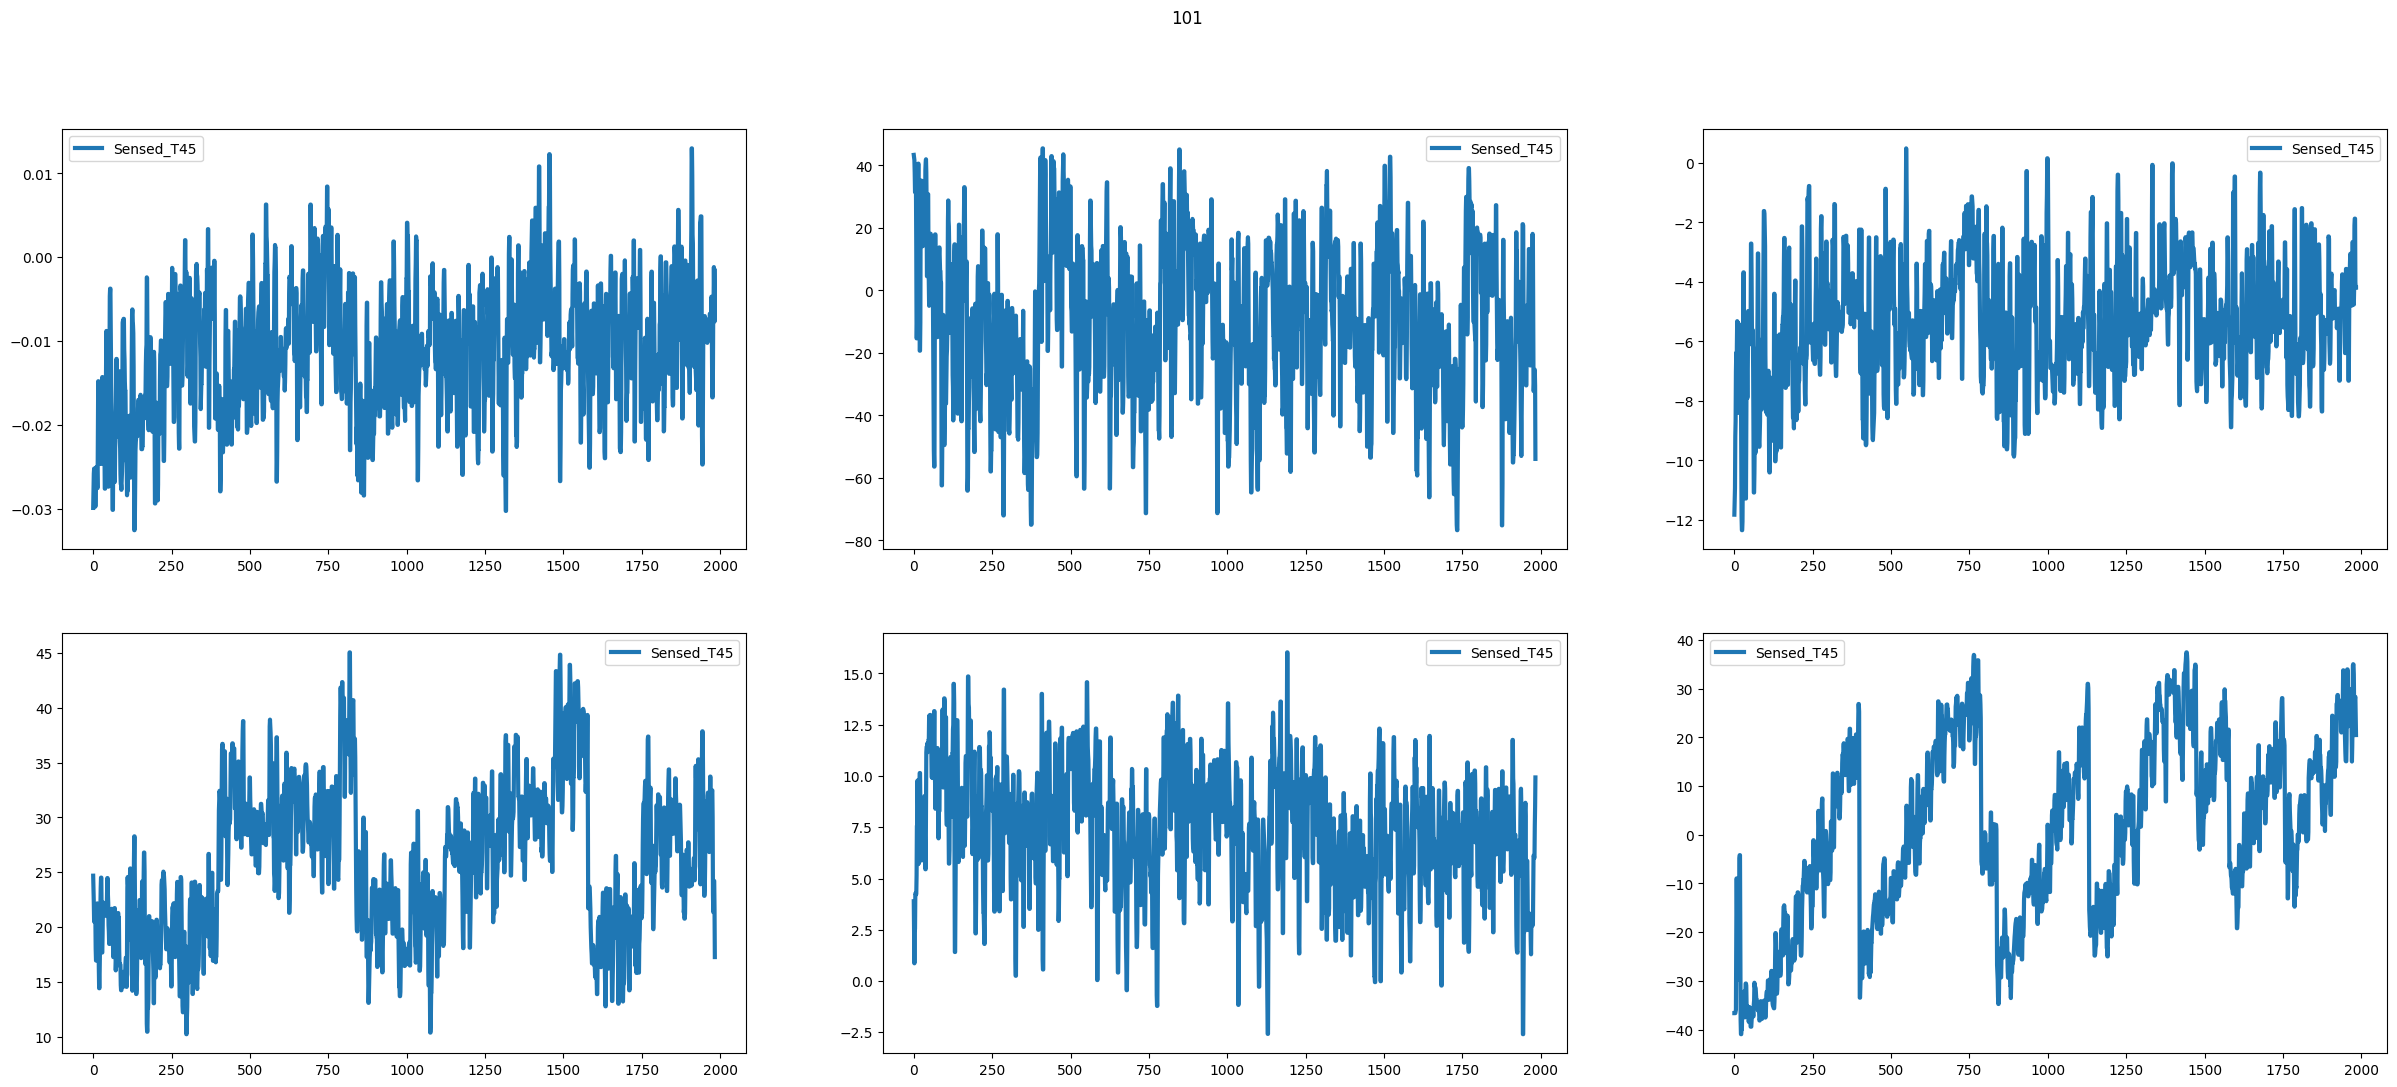

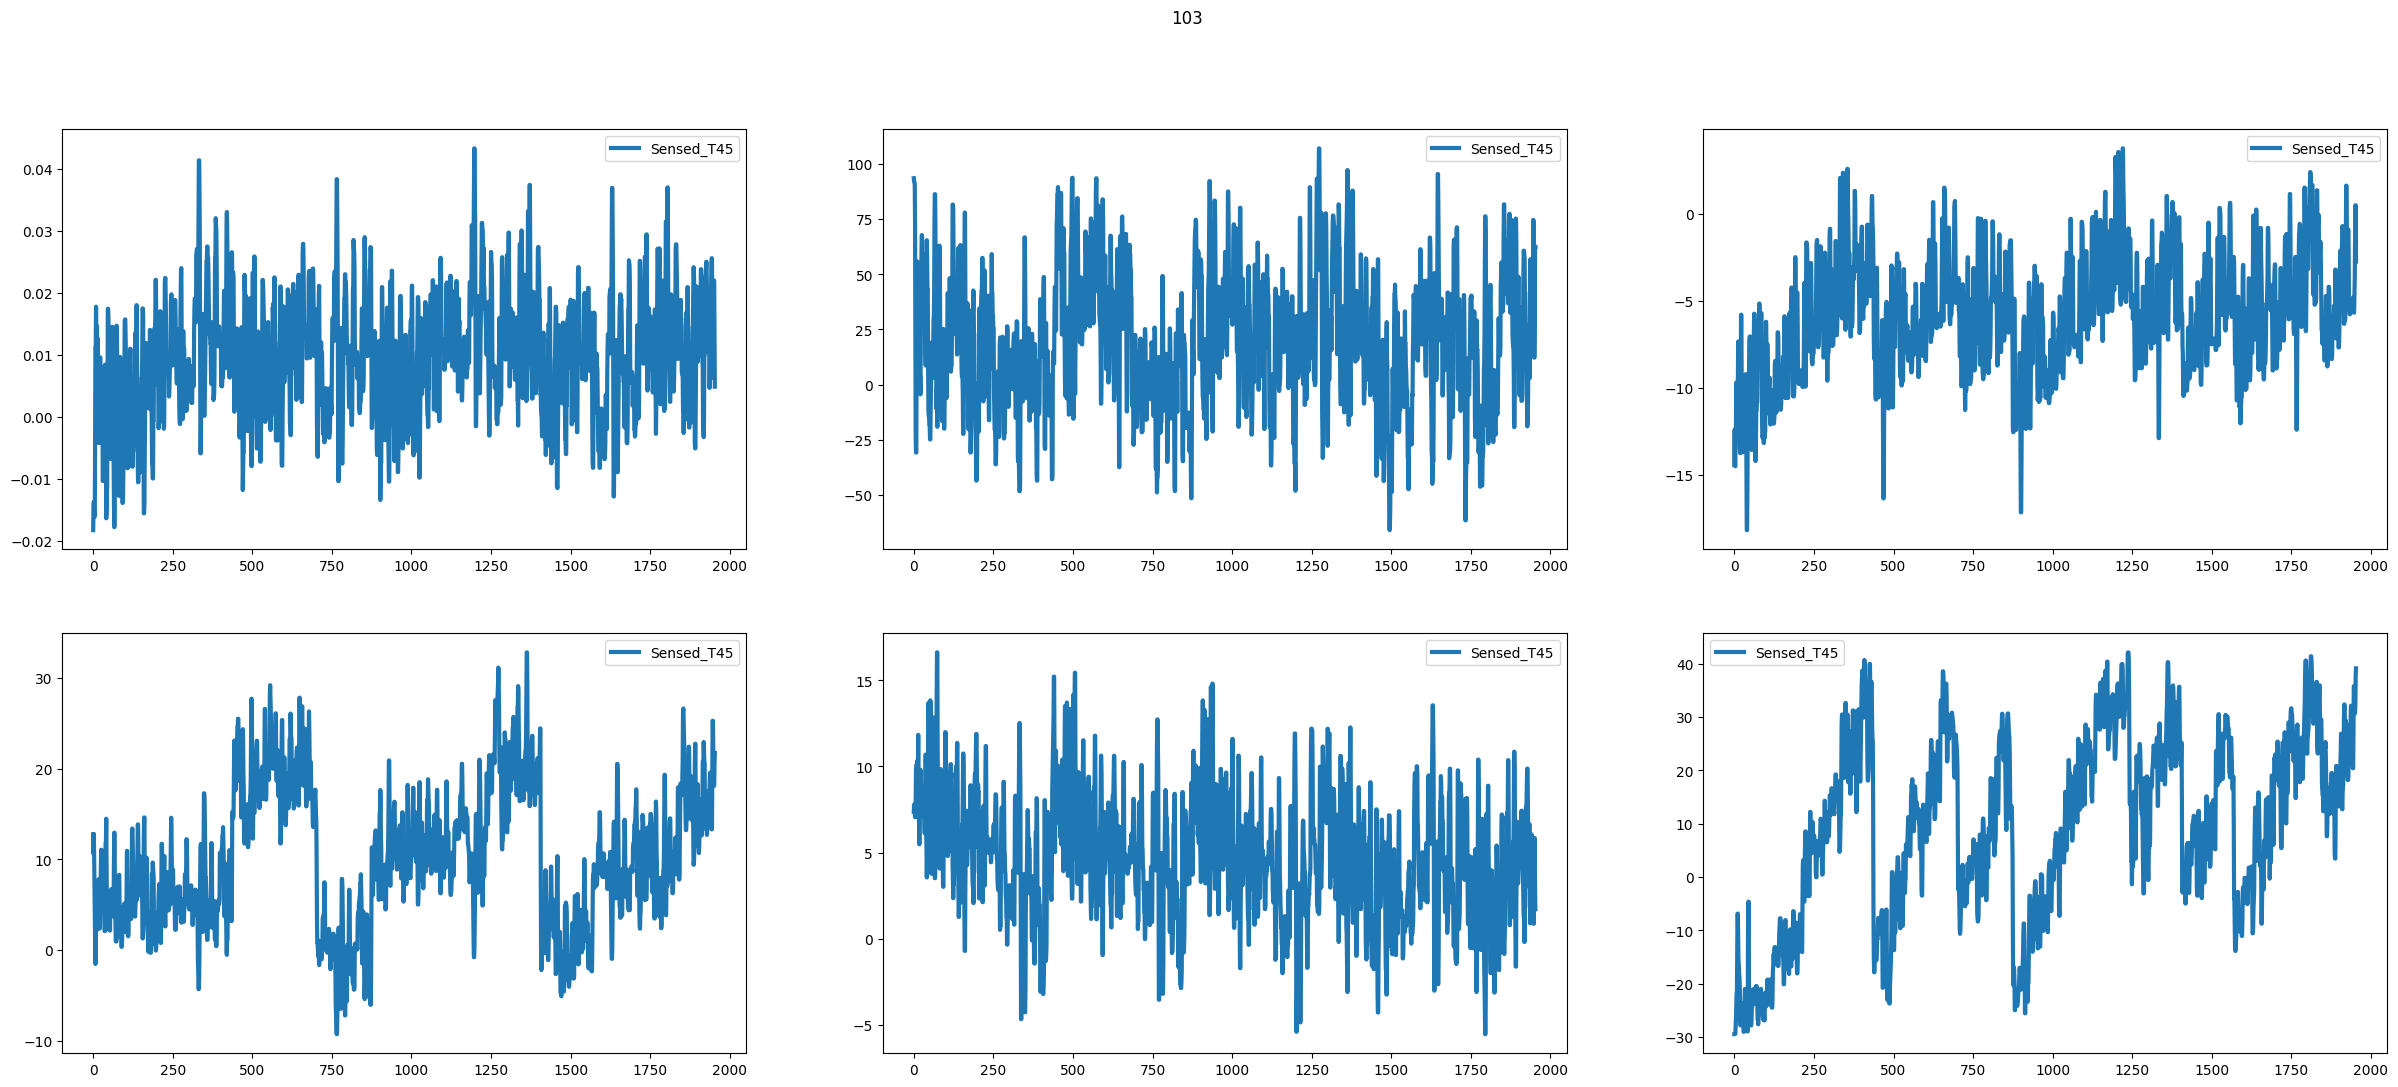

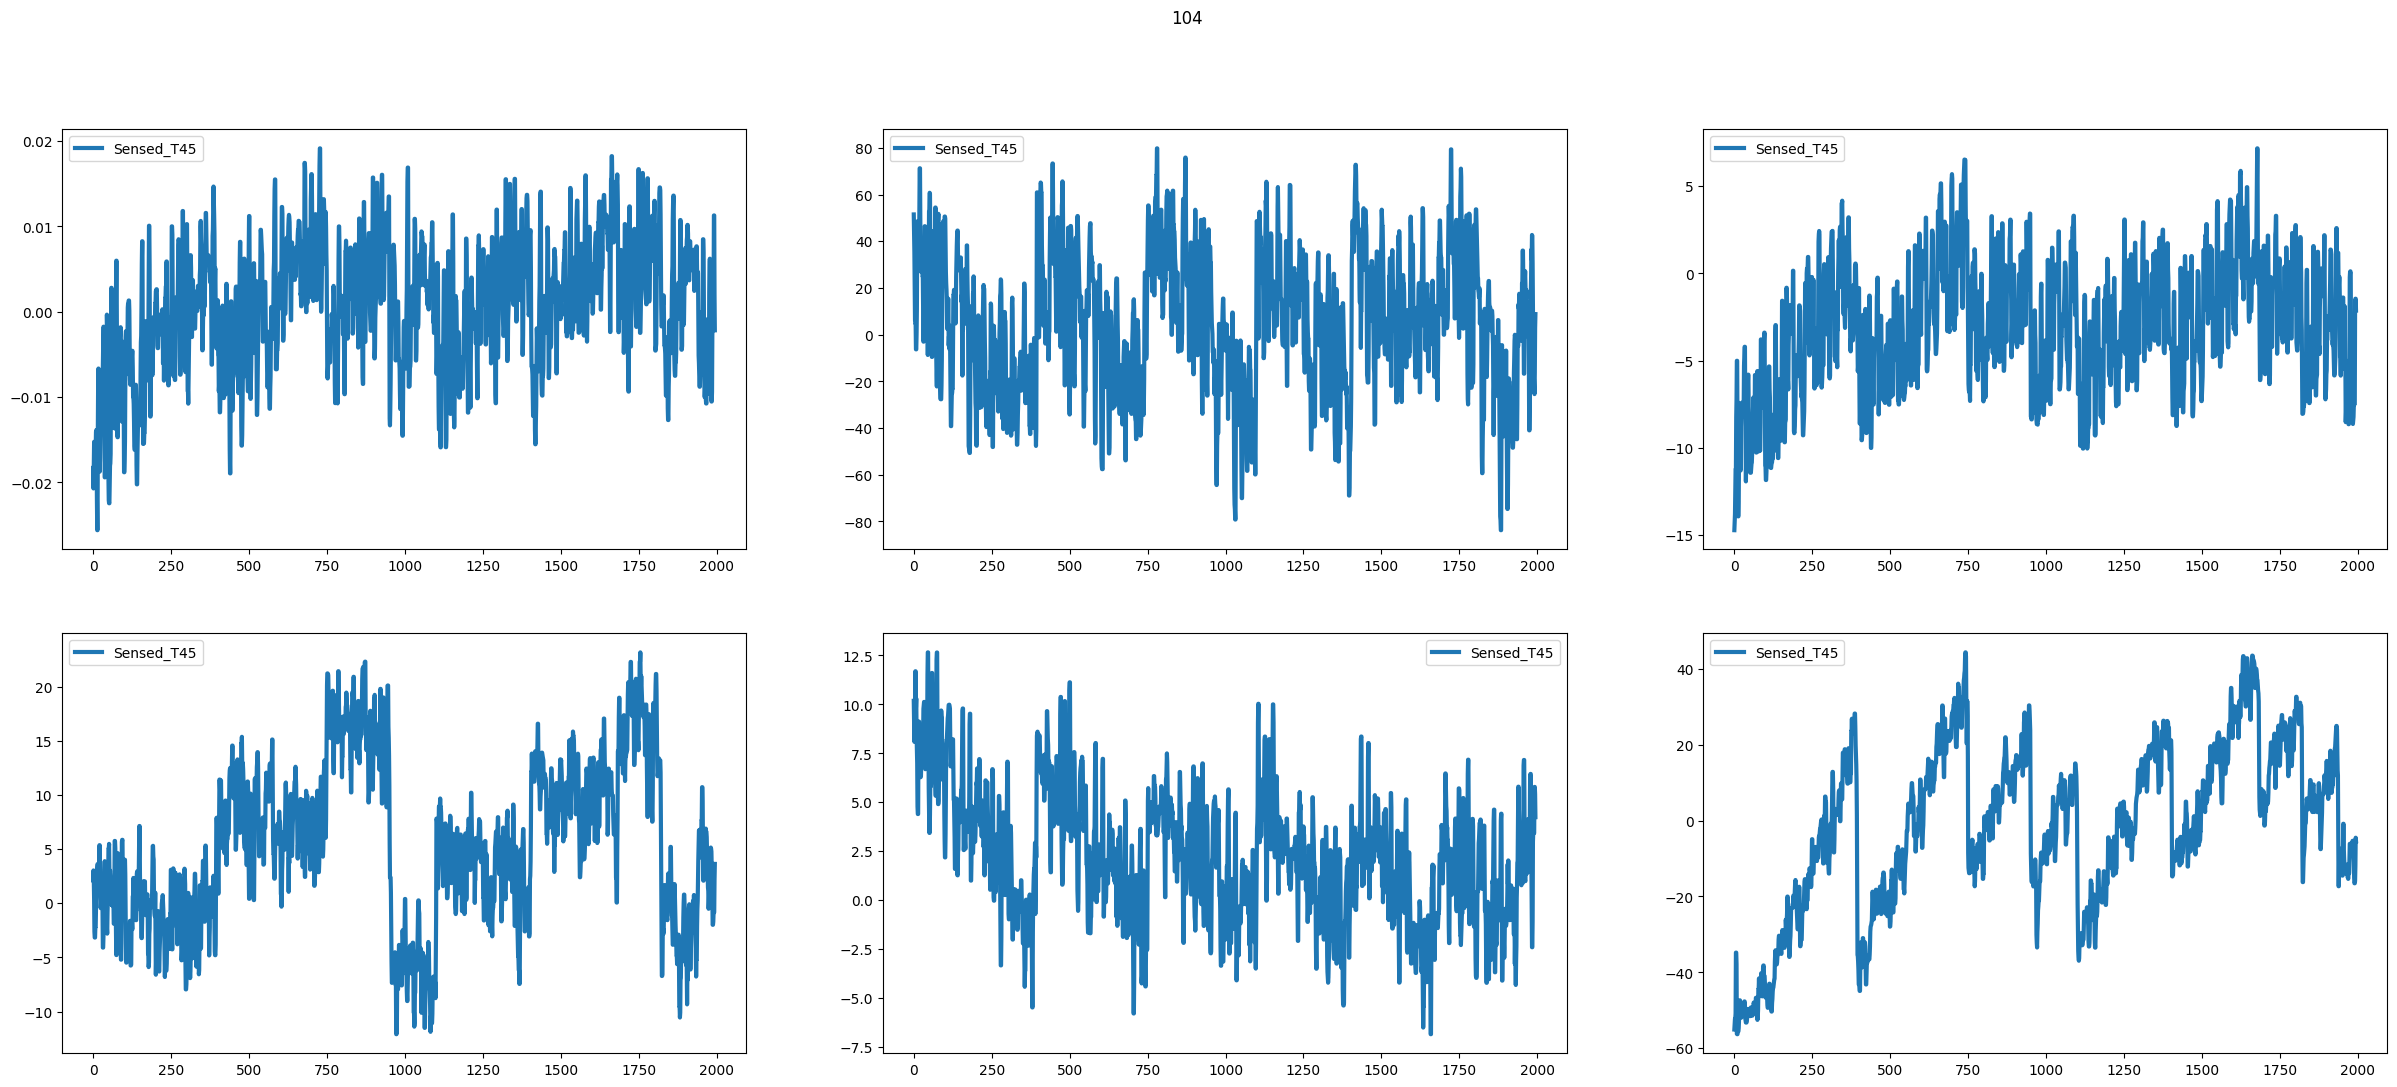

In [65]:
# AGGREGAZIONE SNAPSHOT
cols = ["Cycles_to_HPT_SV", "Cycles_to_HPC_SV", "Cycles_to_WW"]
other_cols_df = [col for col in res_train.columns if col not in managed_cols]
agg_logic = {col: 'median' for col in degradation_vars}
agg_logic.update({col: 'first' for col in other_cols_df + cols})

templ = []
for esn in res_train["ESN"].unique():
  temp = res_train[res_train["ESN"] == esn].copy()
  temp[cols] = df[df["ESN"] == esn][cols]
  temp = temp.groupby('Cycles_Since_New').agg(agg_logic).reset_index(drop=True)
  # temp[degradation_vars] = temp[degradation_vars].rolling(window=10, min_periods=1).mean()
  temp["ESN"] = esn
  templ.append(temp)
res_train = pd.concat(templ)

for esn in res_train.ESN.unique():
  fig, axs = plt.subplots(2,len(degradation_vars)//2, figsize=(30,12))
  fig.suptitle(esn)
  for i,ax in enumerate(axs.flat):
    ax.plot(res_train[res_train["ESN"] == esn][degradation_vars[i]].rolling(window=4, min_periods=1).median(), label=d, linewidth=3)
    ax.legend()
  fig.show()

# train_data_full = res_train.copy()
# res_train.index = res_train.groupby("ESN").cumcount()

Stored 'res_train' (DataFrame)
Stored 'res_val' (DataFrame)
Stored 'hpt_rul_train' (DataFrame)
Stored 'hpc_rul_train' (DataFrame)
Stored 'ww_rul_train' (DataFrame)
Stored 'T3_res_train' (DataFrame)
Stored 'T45_res_train' (DataFrame)
Stored 'hpt_rul_val' (Series)
Stored 'hpc_rul_val' (Series)
Stored 'ww_rul_val' (Series)
Stored 'T3_res_val' (Series)
Stored 'T45_res_val' (Series)
Index(['Sensed_WFuel', 'Sensed_Core_Speed', 'Sensed_T25', 'Sensed_T3',
       'Sensed_Ps3', 'Sensed_T45', 'Cycles_Since_New', 'Snapshot', 'ESN',
       'Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW'],
      dtype='object')


/tmp/ipykernel_13948/2939945162.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_13948/2939945162.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


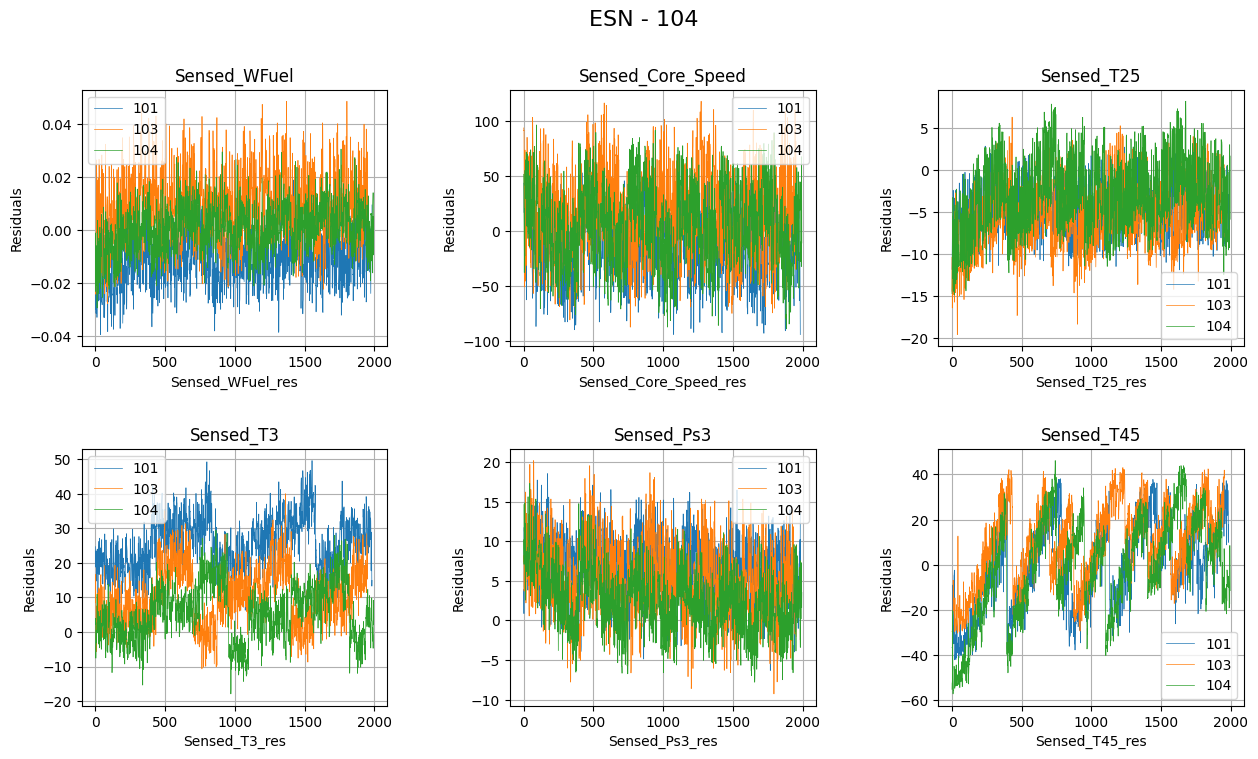

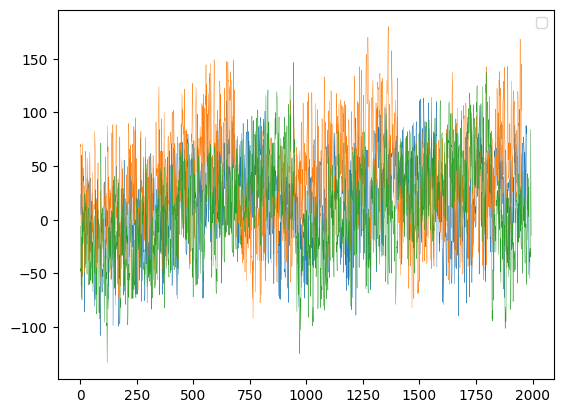

In [66]:

# integrazione residui sul dataset originale
res_val = remove_outliers(res_val, SENSORS, threshold=0.8)
res_val = res_val.rolling(window=10, min_periods=1).mean()
res_val = res_val.dropna()
val_data.update(res_val)


%store res_train
%store res_val

valid_indices_train = res_train.index
hpt_rul_train = train_data_full.loc[valid_indices_train, ["ESN", "Cycles_to_HPT_SV"]]
hpc_rul_train = train_data_full.loc[valid_indices_train, ["ESN", "Cycles_to_HPC_SV"]]
ww_rul_train = train_data_full.loc[valid_indices_train, ["ESN", "Cycles_to_WW"]]
T3_res_train = train_data_full.loc[valid_indices_train, ["ESN", "Sensed_T3"]]
T45_res_train = train_data_full.loc[valid_indices_train, ["ESN", "Sensed_T45"]]

valid_indices_val = res_val.index
hpt_rul_val = val_data.loc[valid_indices_val, "Cycles_to_HPT_SV"]
hpc_rul_val = val_data.loc[valid_indices_val, "Cycles_to_HPC_SV"]
ww_rul_val  = val_data.loc[valid_indices_val, "Cycles_to_WW"]
T3_res_val = res_val["Sensed_T3"]
T45_res_val = res_val["Sensed_T45"]


%store hpt_rul_train
%store hpc_rul_train
%store ww_rul_train
%store T3_res_train
%store T45_res_train
%store hpt_rul_val
%store hpc_rul_val
%store ww_rul_val
%store T3_res_val
%store T45_res_val

# PLOTTING TRAINING
fig, axs = plt.subplots(2,3, figsize=(15,8))
for esn in res_train["ESN"].unique():
  fig.suptitle(f'ESN - {esn}', fontsize=16)
  for i, ax in enumerate(axs.flat):
    if isinstance(ax, plt.Axes):
        degrad = res_train.loc[res_train["ESN"] == esn, degradation_vars[i]].reset_index(drop=True)
        ax.plot(degrad, linewidth=0.5, label=esn)
        ax.set_title(degradation_vars[i])
        ax.set_ylabel("Residuals")
        ax.set_xlabel(f"{degradation_vars[i]}_res")
        ax.legend()
        ax.grid()
  fig.subplots_adjust(hspace=0.4, wspace=0.4)
fig.show()

plt.figure()
for esn in res_train["ESN"].unique():
  prova = res_train[res_train["ESN"] ==  esn][degradation_vars].reset_index(drop=True).sum(axis=1)
  prova.plot(linewidth=0.3)
plt.legend()

print(res_train.columns)


/tmp/ipykernel_13948/3628812022.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_13948/3628812022.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Index(['Sensed_WFuel', 'Sensed_Core_Speed', 'Sensed_T25', 'Sensed_T3',
       'Sensed_Ps3', 'Sensed_T45', 'Cycles_Since_New', 'Snapshot', 'ESN',
       'Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW'],
      dtype='object')


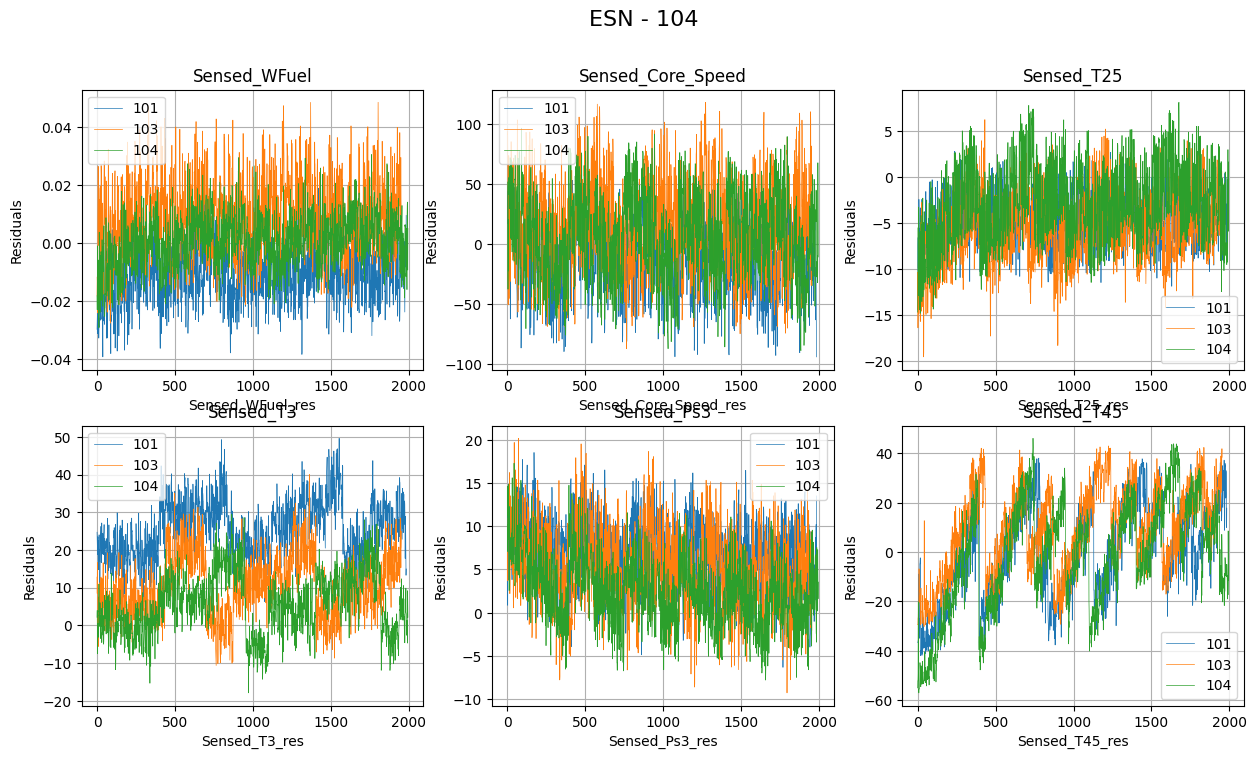

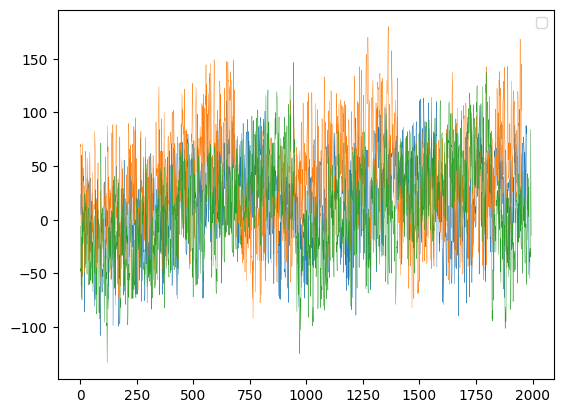

In [67]:

# PLOTTING TRAINING
fig, axs = plt.subplots(2,3, figsize=(15,8))
for esn in res_train["ESN"].unique():
  fig.suptitle(f'ESN - {esn}', fontsize=16)
  for i, ax in enumerate(axs.flat):
    if isinstance(ax, plt.Axes):
        degrad = res_train.loc[res_train["ESN"] == esn, degradation_vars[i]].reset_index(drop=True)
        ax.plot(degrad, linewidth=0.5, label=esn)
        ax.set_title(degradation_vars[i])
        ax.set_ylabel("Residuals")
        ax.set_xlabel(f"{degradation_vars[i]}_res")
        ax.legend()
        ax.grid()
  # fig.subplots_adjust(hspace=0.4, wspace=0.4)
  fig.subplots_adjust()
fig.show()

plt.figure()
for esn in res_train["ESN"].unique():
  prova = res_train[res_train["ESN"] ==  esn][degradation_vars].reset_index(drop=True).sum(axis=1)
  prova.plot(linewidth=0.3)
plt.legend()

print(res_train.columns)


/tmp/ipykernel_13948/2509401662.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(stats.zscore(series, nan_policy='omit'))
/tmp/ipykernel_13948/2509401662.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(stats.zscore(series, nan_policy='omit'))
/tmp/ipykernel_13948/2509401662.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(stats.zscore(series, nan_policy='omit'))
/tmp/ipykernel_13948/2509401662.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Resu

Index(['Sensed_WFuel', 'Sensed_Core_Speed', 'Sensed_T25', 'Sensed_T3',
       'Sensed_Ps3', 'Sensed_T45', 'ESN'],
      dtype='object')
Index(['Sensed_WFuel', 'Sensed_Core_Speed', 'Sensed_T25', 'Sensed_T3',
       'Sensed_Ps3', 'Sensed_T45', 'ESN'],
      dtype='object')
Index(['Sensed_WFuel', 'Sensed_Core_Speed', 'Sensed_T25', 'Sensed_T3',
       'Sensed_Ps3', 'Sensed_T45', 'ESN'],
      dtype='object')
Index(['Sensed_WFuel', 'Sensed_Core_Speed', 'Sensed_T25', 'Sensed_T3',
       'Sensed_Ps3', 'Sensed_T45', 'ESN'],
      dtype='object')


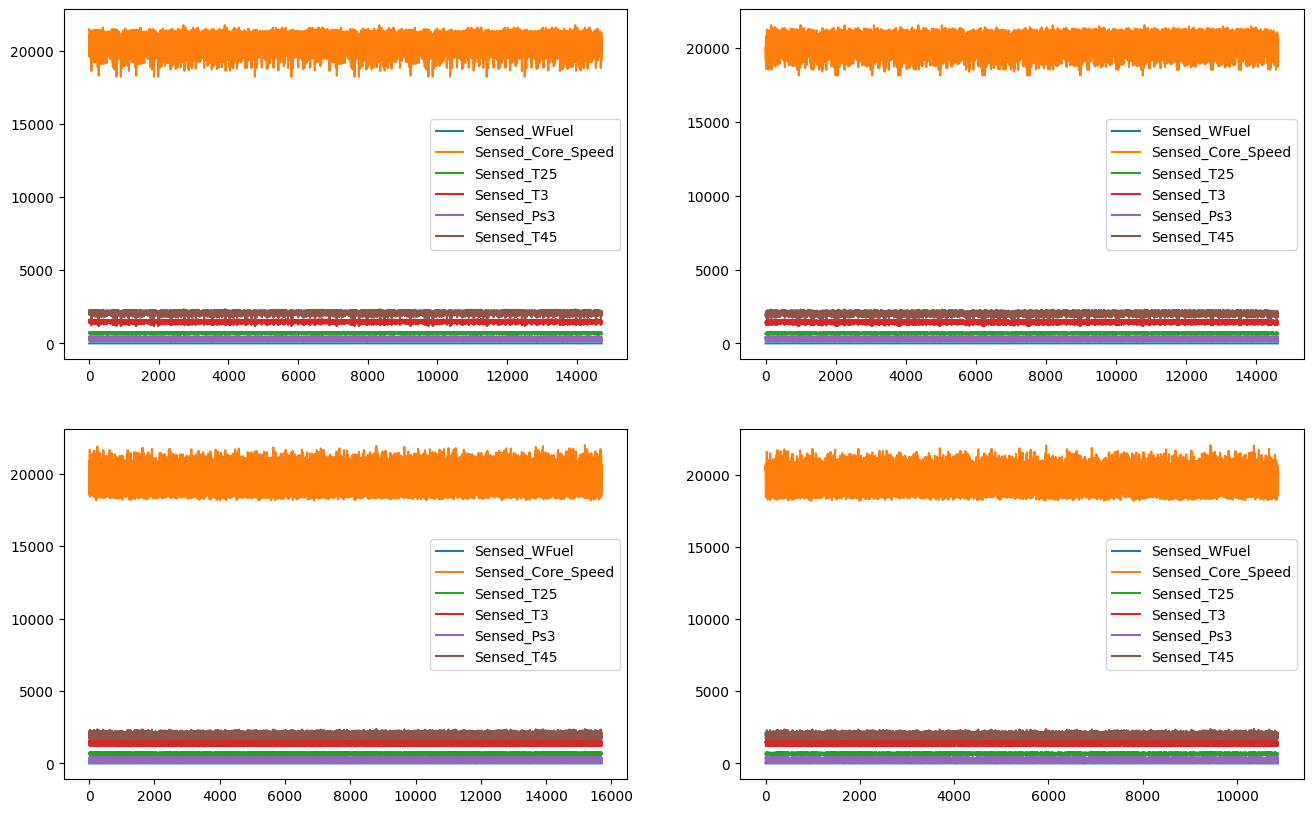

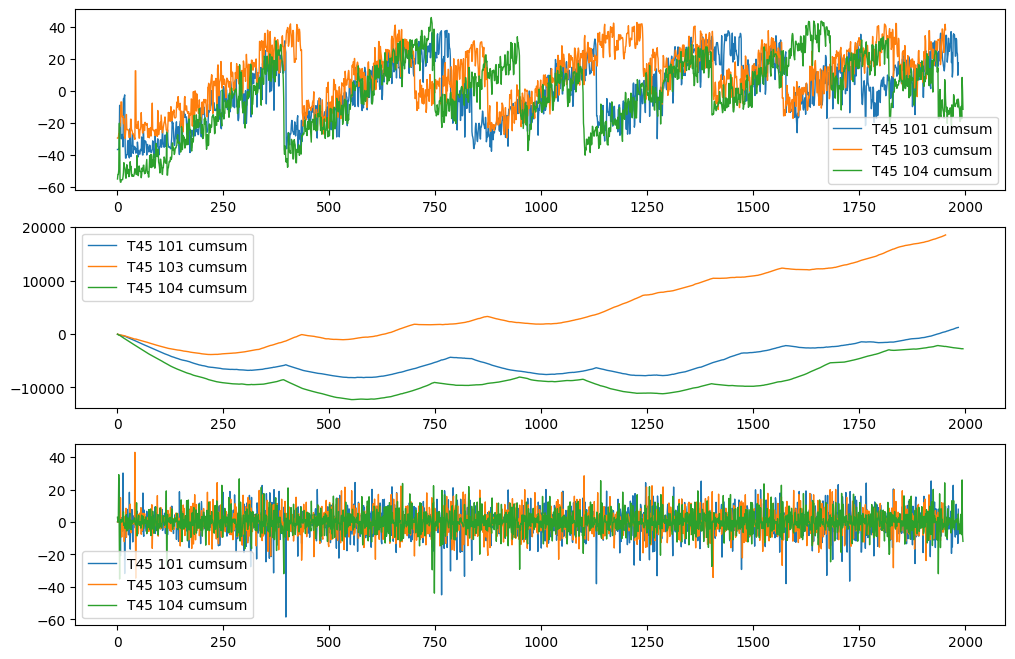

Stored 'res_test' (DataFrame)
Stored 'T3_res_test' (DataFrame)
Stored 'T45_res_test' (DataFrame)


In [68]:
# Calcolo dei residui per i dati di test
res_test = pd.DataFrame()
res_list = []

plt.figure(figsize=(16,10))
for i, esn in enumerate(dfv["ESN"].unique()):
  plt.subplot(2,2,i+1)
  mask = dfv["ESN"] == esn
  X_test = dfv.loc[mask, operating_vars]
  Y_test = dfv.loc[mask, degradation_vars]

  # Predict
  Y_pred = model.predict(X_test)

  plt.plot(Y_pred)
  plt.legend(degradation_vars)

  res_temp = Y_test - Y_pred
  res_temp["ESN"] = esn
  res_temp = remove_outliers(res_temp, res_temp.columns, threshold=0.8)
  res_temp = res_temp.ffill()
  res_temp = res_temp.bfill()

  print(res_temp.columns)

  res_list.append(res_temp)

plt.show()

res_test = pd.concat(res_list)

plt.figure(figsize=(12,8))
plt.subplot(3,1,1)
for esn in res_train["ESN"].unique():
  data = res_train.loc[res_train["ESN"] == esn, "Sensed_T45"].reset_index(drop=True)
  plt.plot(data, linewidth=1, label=f"T45 {esn} cumsum")
  plt.legend()

plt.subplot(3,1,2)
for esn in res_train["ESN"].unique():
  data = res_train.loc[res_train["ESN"] == esn, "Sensed_T45"].reset_index(drop=True)
  plt.plot(data.cumsum(), linewidth=1, label=f"T45 {esn} cumsum")
  plt.legend()

plt.subplot(3,1,3)
for esn in res_train["ESN"].unique():
  data = res_train.loc[res_train["ESN"] == esn, "Sensed_T45"].reset_index(drop=True)
  plt.plot(data.diff(), linewidth=1, label=f"T45 {esn} cumsum")
  plt.legend()
plt.show()


#PULIZIA E ROLLING
cleaned_chunks = []
for esn in dfv["ESN"].unique():
  temp = res_test[res_test["ESN"] == esn].copy()
  temp = remove_outliers(temp, SENSORS, threshold=0.1)
  temp[degradation_vars] = temp[degradation_vars].rolling(window=50, min_periods=1).mean()
  cleaned_chunks.append(temp)

res_test = pd.concat(cleaned_chunks).dropna()
res_test.index = res_test.groupby("ESN").cumcount()

T3_res_test = res_test[["ESN", "Sensed_T3"]].copy()
T45_res_test = res_test[["ESN", "Sensed_T45"]].copy()

# Store dei risultati
%store res_test
%store T3_res_test
%store T45_res_test

/tmp/ipykernel_13948/2943021838.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


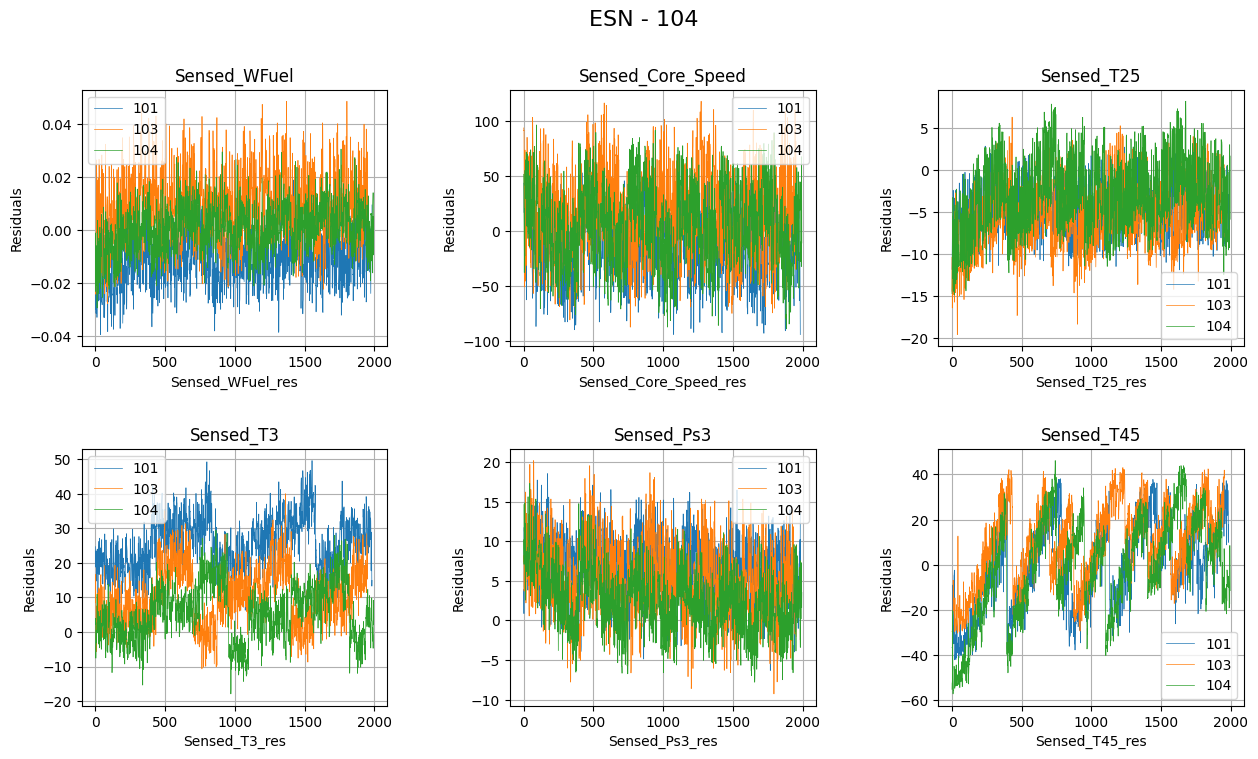

In [69]:
# PLOTTING TRAINING
fig, axs = plt.subplots(2,3, figsize=(15,8))
for esn in res_train["ESN"].unique():
  fig.suptitle(f'ESN - {esn}', fontsize=16)
  for i, ax in enumerate(axs.flat):
    if isinstance(ax, plt.Axes):
        degrad = res_train.loc[res_train["ESN"] == esn, degradation_vars[i]].reset_index(drop=True)
        ax.plot(degrad, linewidth=0.5, label=esn)
        ax.set_title(degradation_vars[i])
        ax.set_ylabel("Residuals")
        ax.set_xlabel(f"{degradation_vars[i]}_res")
        ax.legend()
        ax.grid()
  fig.subplots_adjust(hspace=0.4, wspace=0.4)
fig.show()

/tmp/ipykernel_13948/1237933977.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


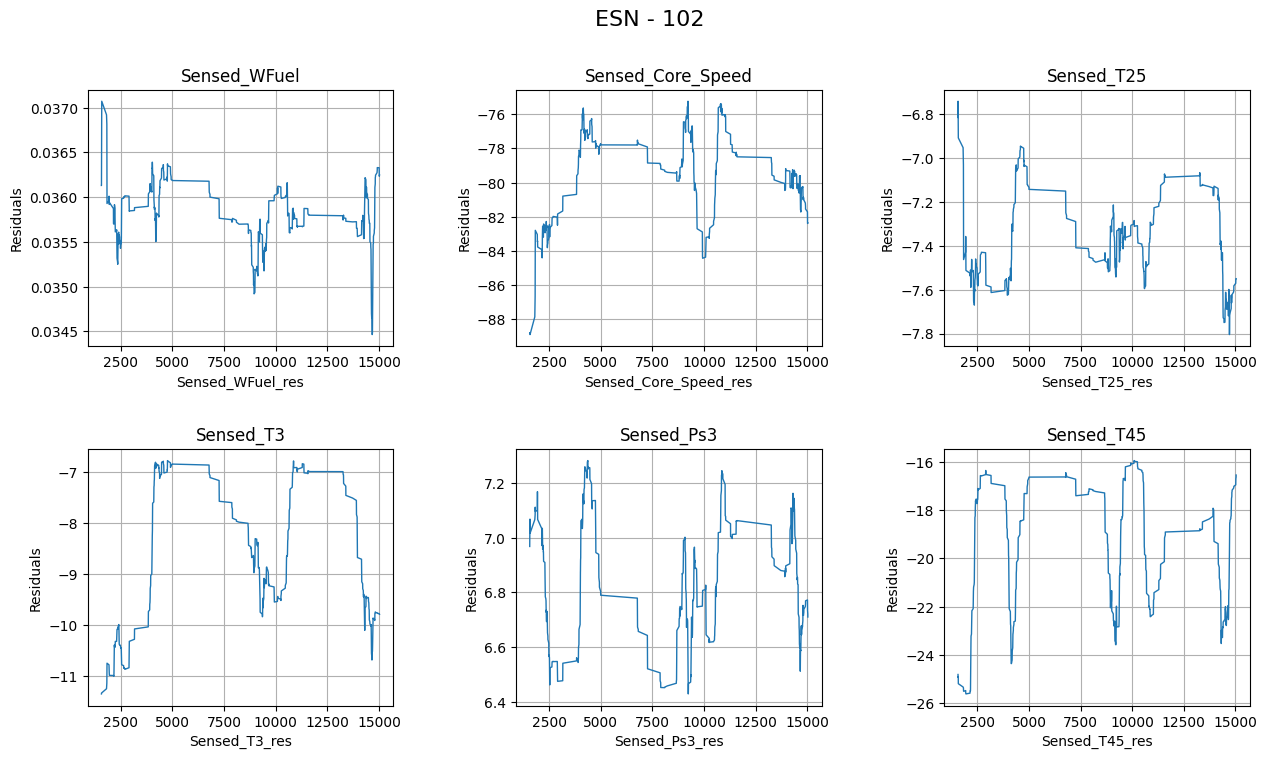

In [70]:
# PLOTTING VALIDATION
fig, axs = plt.subplots(2,3, figsize=(15,8))
fig.suptitle(f'ESN - {testing_esn}', fontsize=16)
for i, ax in enumerate(axs.flat):
    if isinstance(ax, plt.Axes):
        ax.plot(res_val.loc[:, degradation_vars[i]].rolling(window=95, min_periods=1).mean(), linewidth=1)
        ax.set_title(degradation_vars[i])
        ax.set_ylabel("Residuals")
        ax.set_xlabel(f"{degradation_vars[i]}_res")
        ax.grid()
fig.subplots_adjust(hspace=0.4, wspace=0.4)
fig.show()

/tmp/ipykernel_13948/2831350362.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


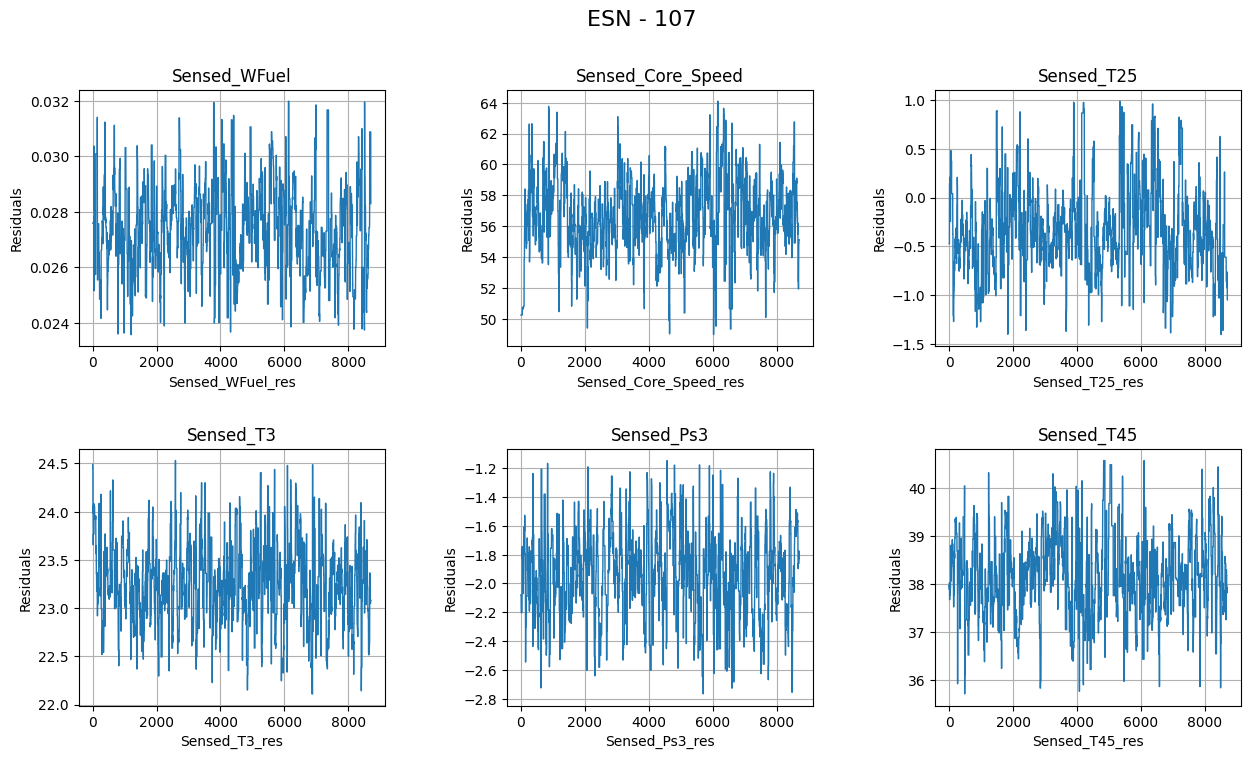

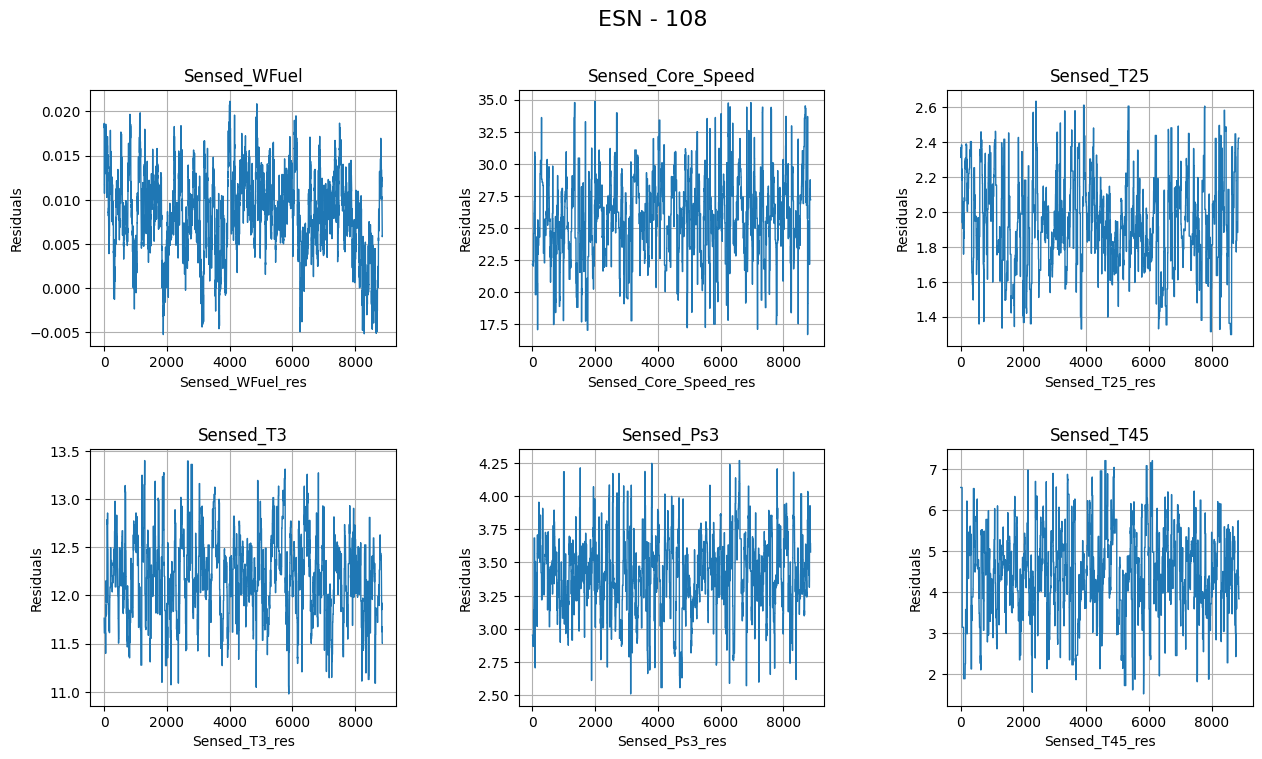

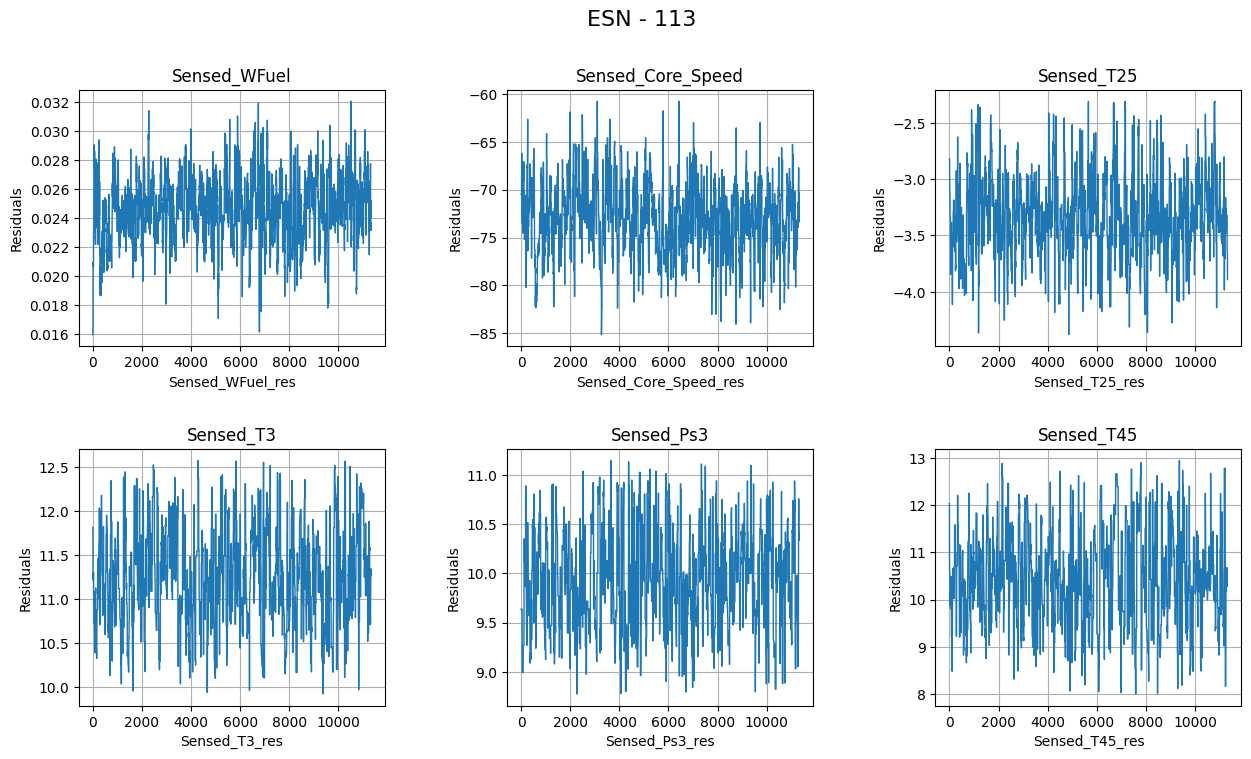

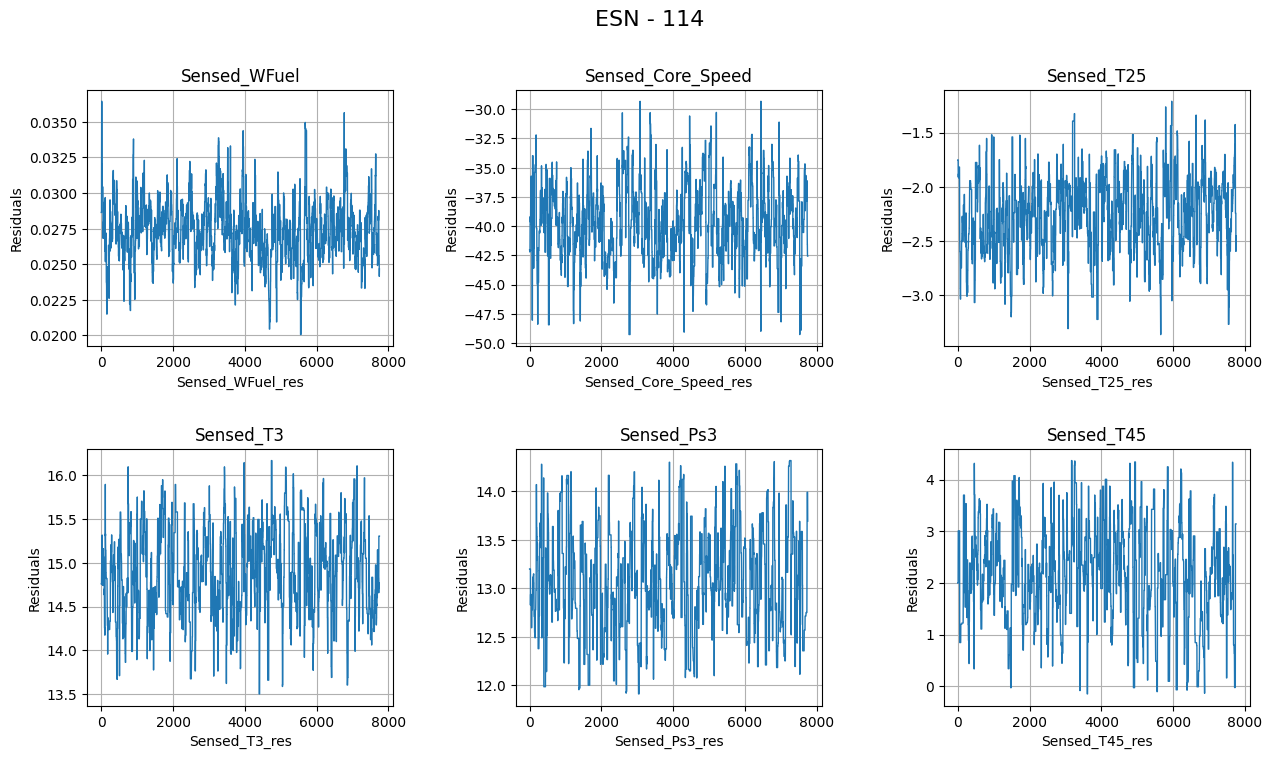

In [71]:
# PLOTTING TEST
for esn in dfv["ESN"].unique():
  fig, axs = plt.subplots(2,3, figsize=(15,8))
  fig.suptitle(f'ESN - {esn}', fontsize=16)
  for i, ax in enumerate(axs.flat):
    if isinstance(ax, plt.Axes):
        ax.plot(res_test.loc[res_test["ESN"] == esn, degradation_vars[i]], linewidth=1)
        ax.set_title(degradation_vars[i])
        ax.set_ylabel("Residuals")
        ax.set_xlabel(f"{degradation_vars[i]}_res")
        ax.grid()
  fig.subplots_adjust(hspace=0.4, wspace=0.4)
  fig.show()

# HPT e HPC
## Ricerca di a,b,c,d,e,f,g globali combinazione lineare di tutti i sensori

In [72]:
# Standardizzazione dei residui

# Dati di training
train_chunks = []
dict_mins = {var: [] for var in degradation_vars}
dict_maxs = {var: [] for var in degradation_vars}
for esn in res_train["ESN"].unique():
    mask = res_train["ESN"] == esn
    # mask_hpt = hpt_rul_train["ESN"] == esn
    # hpt_rul_train.loc[mask, "Cycles_to_HPT_SV"] = minmax(hpt_rul_train[mask_hpt], "Cycles_to_HPT_SV")
    # mask_hpc = hpc_rul_train["ESN"] == esn
    # hpc_rul_train.loc[mask, "Cycles_to_HPC_SV"] = minmax(hpc_rul_train[mask_hpc], "Cycles_to_HPC_SV")
    # mask_ww = ww_rul_train["ESN"] == esn
    # ww_rul_train.loc[mask, "Cycles_to_WW"] = minmax(ww_rul_train[mask_ww], "Cycles_to_WW")
    hpt_rul = res_train[mask]["Cycles_to_HPT_SV"]
    hpc_rul = res_train[mask]["Cycles_to_HPC_SV"]
    ww_rul = res_train[mask]["Cycles_to_WW"]
    for var in degradation_vars:
        dict_mins[var].append(res_train.loc[mask, var].min())
        dict_maxs[var].append(res_train.loc[mask, var].max())
        res_train.loc[mask, var] = minmax(res_train.loc[mask], var)
avg_mins_per_var = {var: np.mean(lst) for var, lst in dict_mins.items()}
avg_maxs_per_var = {var: np.mean(lst) for var, lst in dict_maxs.items()}

print(f'Scaled: {res_train}')

# Dati di validation
for var in degradation_vars:
    res_val.loc[var] = minmax(res_val, var)
hpt_rul_val_scaled = normalize(hpt_rul_val)
hpc_rul_val_scaled = normalize(hpc_rul_val)
ww_rul_val_scaled = normalize(ww_rul_val)


# Dati di test
for esn in dfv["ESN"].unique():
    mask = res_test["ESN"] == esn
    for var in degradation_vars:
        # Usa i limiti medi del training
        m = avg_mins_per_var[var]
        M = avg_maxs_per_var[var]
        res_test.loc[mask, var] = (res_test.loc[mask, var] - m) / (M - m)



%store res_train
%store res_val
%store res_test
%store hpt_rul_train
%store hpc_rul_train
%store ww_rul_train
%store hpt_rul_val_scaled
%store hpc_rul_val_scaled
%store ww_rul_val_scaled
%store avg_mins_per_var
%store avg_maxs_per_var

Scaled:       Sensed_WFuel  Sensed_Core_Speed  Sensed_T25  Sensed_T3  Sensed_Ps3  \
0         0.151666           0.913028    0.092592   0.424618    0.410878   
1         0.216976           0.902016    0.147871   0.367694    0.288730   
2         0.236205           0.849232    0.363149   0.287753    0.289089   
3         0.258827           0.735196    0.417687   0.287753    0.727016   
4         0.127737           0.818886    0.211175   0.373889    0.424721   
...            ...                ...         ...        ...         ...   
1990      0.710898           0.305451    0.775519   0.360912    0.544882   
1991      0.725506           0.356696    0.775519   0.278883    0.600939   
1992      0.334915           0.844316    0.388807   0.572036    0.507485   
1993      0.333918           0.634785    0.388807   0.487681    0.374781   
1994      0.573480           0.421273    0.716700   0.422860    0.451623   

      Sensed_T45  Cycles_Since_New  Snapshot  ESN  Cycles_to_HPT_SV  \
0       

In [73]:
# Preprocessing per il training dell'ottimizzatore ottimizzatore

all_train_res = []
all_train_hpt_rul = []
all_train_hpc_rul = []
all_train_ww_rul = []

for esn in res_train["ESN"].unique():
    res_esn = res_train.loc[res_train["ESN"] == esn, ["ESN"] + degradation_vars]

    rul_hpt_esn = hpt_rul_train.loc[hpt_rul_train["ESN"] == esn]
    rul_hpc_esn = hpc_rul_train.loc[hpc_rul_train["ESN"] == esn]
    rul_ww_esn = ww_rul_train.loc[ww_rul_train["ESN"] == esn]

    all_train_res.append(res_esn)
    all_train_hpt_rul.append(rul_hpt_esn)
    all_train_hpc_rul.append(rul_hpc_esn)
    all_train_ww_rul.append(rul_ww_esn)


# Impiliamo tutto: diventano quattro matrici uniche
X_train_opt = pd.concat(all_train_res, ignore_index=True)
Y_train_hpt = pd.concat(all_train_hpt_rul, ignore_index=True)
Y_train_hpc = pd.concat(all_train_hpc_rul, ignore_index=True)
Y_train_ww = pd.concat(all_train_ww_rul, ignore_index=True)

In [78]:
bounds = [
    (-1, 1),  # a
    (-1, 1),  # b
    (-1, 1),  # c
    (-1, 1),  # d
    (-1, 1),  # e
    (-1, 1),  # f
]

all_coefs_hpt = []
all_coefs_hpc = []
# all_coefs_ww = []

for esn in res_train["ESN"].unique():
  result_hpt = differential_evolution(
      objective_deviation,
      bounds=bounds,
      args=(X_train_opt.loc[X_train_opt["ESN"] == esn, degradation_vars], Y_train_hpt.loc[Y_train_hpt["ESN"] == esn, "Cycles_to_HPT_SV"]),
      strategy='best1bin',
      maxiter=600,                # generazioni
      popsize=100,
      workers=-1,
      tol=0.02,                      # Tolleranza
  )
  all_coefs_hpt.append(result_hpt.x)

  result_hpc = differential_evolution(
      objective_deviation,
      bounds=bounds,
      args=(X_train_opt.loc[X_train_opt["ESN"] == esn, degradation_vars], Y_train_hpc.loc[Y_train_hpc["ESN"] == esn, "Cycles_to_HPC_SV"]),
      strategy='best1bin',
      maxiter=600,                # generazioni
      popsize=100,
      workers=-1,
      tol=0.001,                      # Tolleranza
  )
  all_coefs_hpc.append(result_hpc.x)

  # result_ww = differential_evolution(
  #     objective_deviation,
  #     bounds=bounds,
  #     args=(X_train_opt.loc[X_train_opt["ESN"] == esn, degradation_vars], Y_train_ww.loc[Y_train_ww["ESN"] == esn, "Cycles_to_WW"]),
  #     strategy='best1bin',
  #     maxiter=400,                # generazioni
  #     popsize=100,
  #     workers=-1,
  #     tol=0,                      # Tolleranza
  # )
  # all_coefs_ww.append(result_ww.x)

coefs_hpt = np.mean(all_coefs_hpt, axis=0)
coefs_hpc = np.mean(all_coefs_hpc, axis=0)
# coefs_ww  = np.mean(all_coefs_ww, axis=0)

# Stampa dei risultati medi
print("\nCOEFFICIENTI MEDI FINALI (Training Set):")
print(f"HPT: {coefs_hpt}")
print(f"HPC: {coefs_hpc}")
# print(f"WW:  {coefs_ww}")

# Store dei coefficienti medi per il testing
%store coefs_hpt
%store coefs_hpc
# %store coefs_ww

/home/began/desk/phm-america-2025/.venv/lib/python3.10/site-packages/scipy/optimize/_differentialevolution.py:486: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/began/desk/phm-america-2025/.venv/lib/python3.10/site-packages/scipy/optimize/_differentialevolution.py:486: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/began/desk/phm-america-2025/.venv/lib/python3.10/site-packages/scipy/optimize/_differentialevolution.py:486: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/began/desk/phm-america-2025/.venv/lib/python3.10/site-packages/scipy/optimize/_differentialevolution.py:486: UserWa


COEFFICIENTI MEDI FINALI (Training Set):
HPT: [-3.25051845 -1.30326949 -2.79572657 -1.6546684   1.28047409 -3.06583629]
HPC: [ 6.56571436 -4.15254605 -3.98586221  2.5092515  -3.09432992 -3.70538354]
Stored 'coefs_hpt' (ndarray)
Stored 'coefs_hpc' (ndarray)


In [ ]:
# PARAMETRI DI TEST SOLO PER HPT E HPC
coefs_hpt = [-3.25051845,-1.30326949,-2.79572657,-1.6546684, 1.28047409,-3.06583629]
coefs_hpc = [6.56571436,-4.15254605,-3.98586221, 2.5092515, -3.09432992,-3.70538354]

# coefs_hpt = [276.19439386,
#               -343.90020315,
#               781.45341037,
#               -593.41135514,
#               -190.36846837,
#               118.5466599]

# coefs_hpc = [354.11354513,
#              295.34981181,
#              -386.49672567,
#              790.99844931,
#              -679.69393928,
#              487.61887153]

%store coefs_hpt
%store coefs_hpc

Stored 'coefs_hpt' (list)
Stored 'coefs_hpc' (list)


/tmp/ipykernel_13948/2428438007.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_13948/2428438007.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_13948/2428438007.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Limiti Medi HPT: Min=0.0000, Max=1.0000
Stored 'avg_min_hpt' (float64)
Stored 'avg_max_hpt' (float64)
Stored 'avg_min_hpc' (float64)
Stored 'avg_max_hpc' (float64)


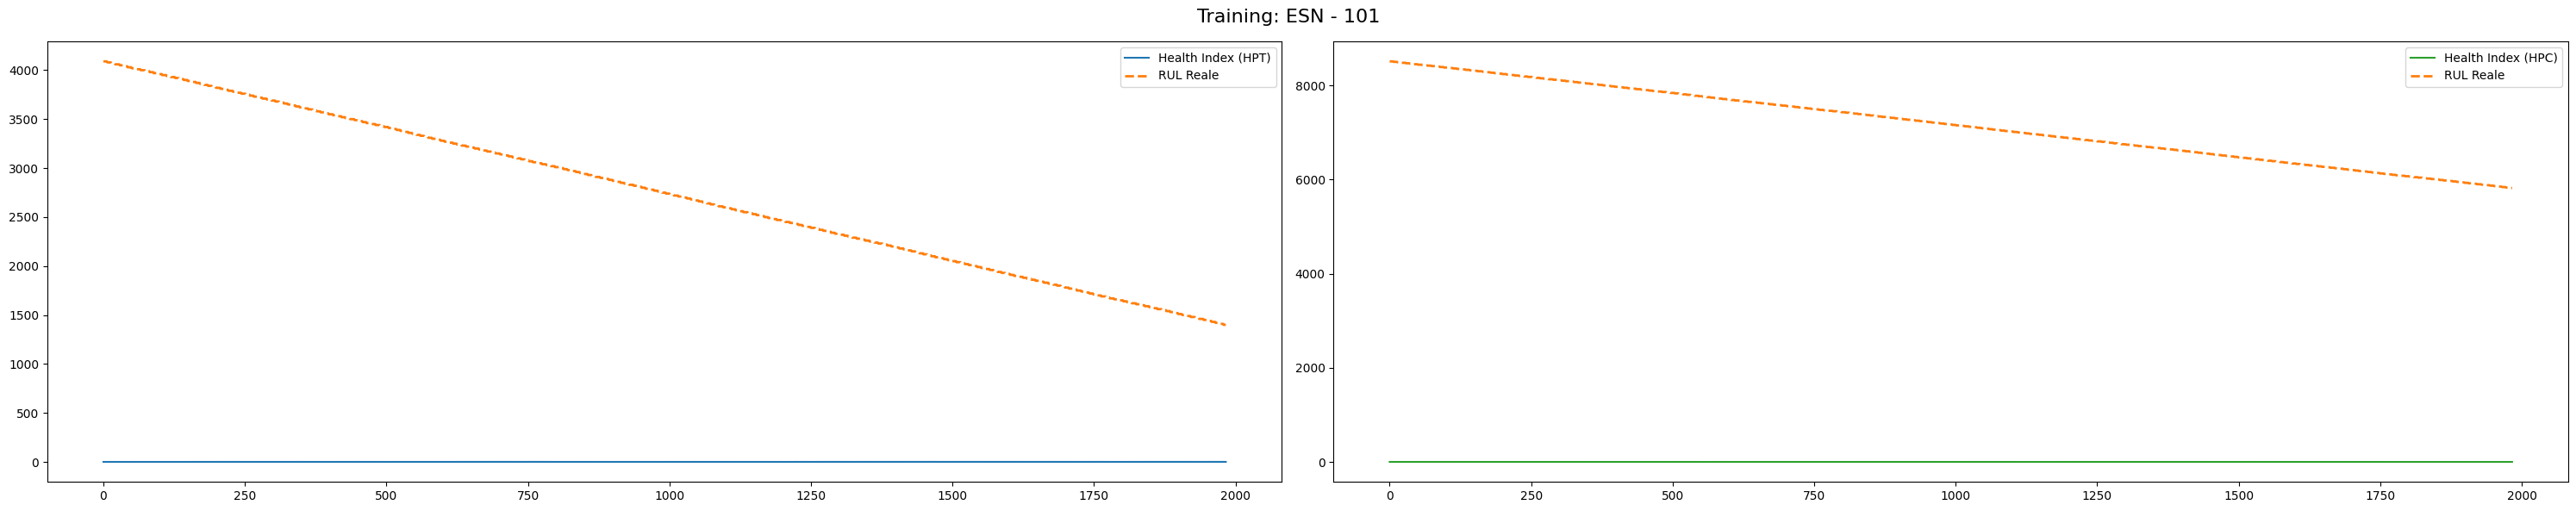

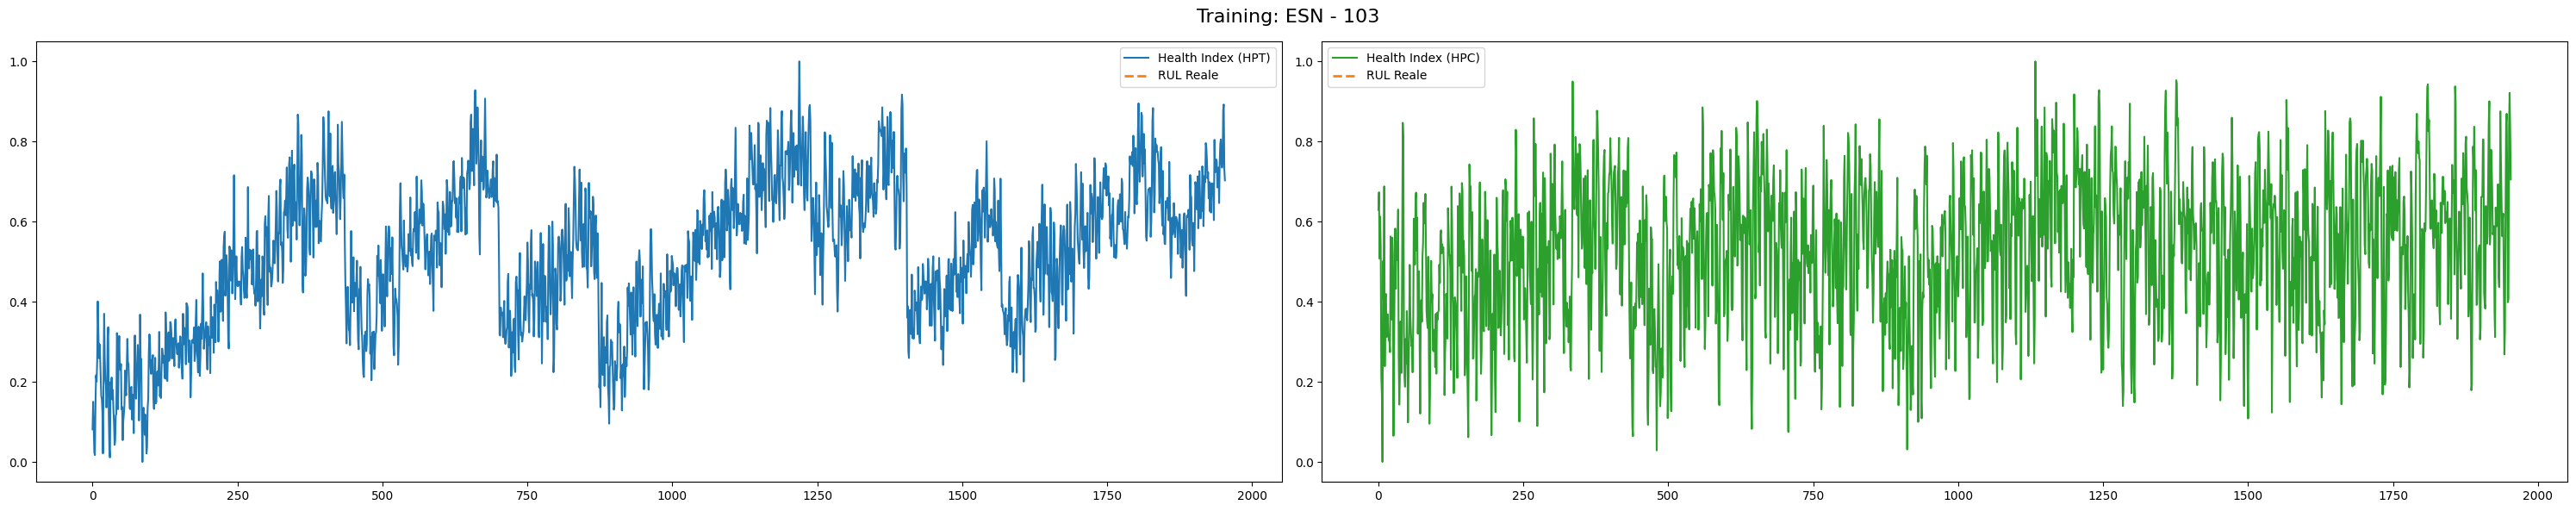

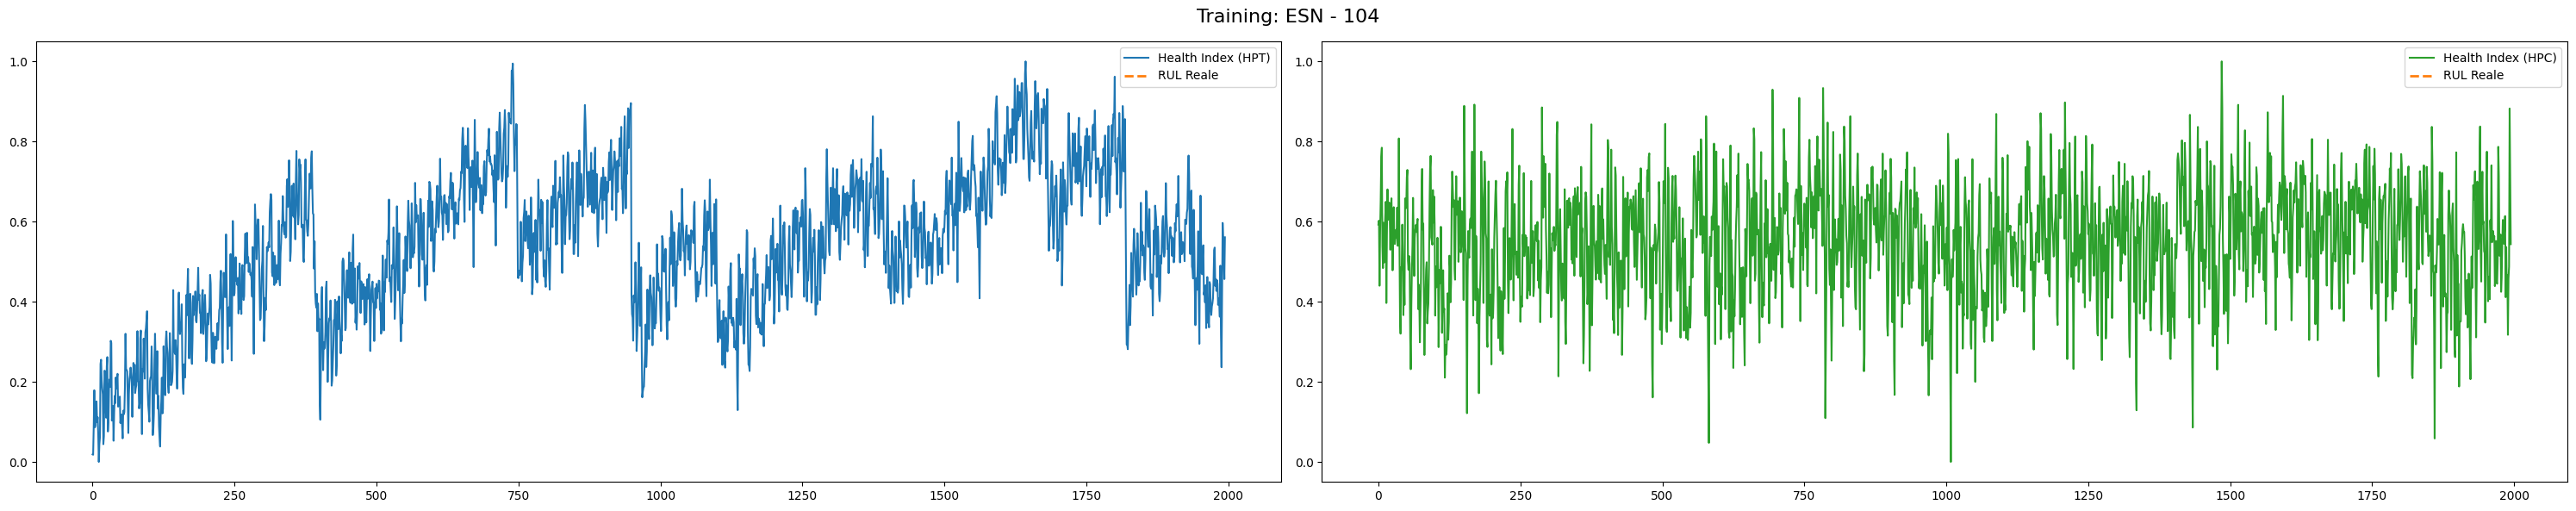

In [79]:
# PLOTTING SU DATI DI TRAINING

hpt_limits, hpc_limits, ww_limits = [], [], []
for esn in res_train["ESN"].unique():
  temp = res_train[res_train["ESN"] == esn].copy()
  
  # Calcolo e standardizzazione degli health index
  hi_hpt = normalize(HIE(coefs_hpt, temp[degradation_vars]))
  hi_hpc = normalize(HIE(coefs_hpc, temp[degradation_vars]))
  # hi_ww = normalize(HIE(coefs_ww, temp[degradation_vars]))

  hpt_limits.append((hi_hpt.min(), hi_hpt.max()))
  hpc_limits.append((hi_hpc.min(), hi_hpc.max()))
  # ww_limits.append((hi_ww.min(), hi_ww.max()))

  # Definizione delle RUL efettive
  hpt_rul_esn = hpt_rul_train[hpt_rul_train["ESN"] == esn].copy()
  hpc_rul_esn = hpc_rul_train[hpc_rul_train["ESN"] == esn].copy()
  ww_rul_esn  = ww_rul_train[ww_rul_train["ESN"] == esn].copy()

  fig, axs = plt.subplots(1, 2, figsize=(30, 6))
  fig.suptitle(f'Training: ESN - {esn}', fontsize=16)
  axs[0].plot(hi_hpt, color='tab:blue', label='Health Index (HPT)')
  axs[0].plot(temp["Cycles_to_HPT_SV"], color='tab:orange', linewidth=2, linestyle='--', label='RUL Reale')
  axs[0].legend()

  axs[1].plot(hi_hpc, color='tab:green', label='Health Index (HPC)')
  axs[1].plot(temp["Cycles_to_HPC_SV"], color='tab:orange', linewidth=2, linestyle='--', label='RUL Reale')
  axs[1].legend()
  # axs[2].plot(hi_ww, color='tab:green', label='Health Index (HPC)')
  # axs[2].plot(ww_rul_esn["Cycles_to_WW"], color='tab:orange', linewidth=2, linestyle='--', label='RUL Reale')
  fig.tight_layout()
  fig.show()


def get_avg_limits(limits_list):
    mins = [l[0] for l in limits_list]
    maxs = [l[1] for l in limits_list]
    return np.mean(mins), np.mean(maxs)

# Calcolo limiti medi finali
avg_min_hpt, avg_max_hpt = get_avg_limits(hpt_limits)
avg_min_hpc, avg_max_hpc = get_avg_limits(hpc_limits)
# avg_min_ww,  avg_max_ww  = get_avg_limits(ww_limits)

print(f"Limiti Medi HPT: Min={avg_min_hpt:.4f}, Max={avg_max_hpt:.4f}")

# Store per usarli nel notebook del Testing
%store avg_min_hpt
%store avg_max_hpt
%store avg_min_hpc
%store avg_max_hpc
# %store avg_min_ww
# %store avg_max_ww

In [ ]:
# PLOTTING SU DATI DI VALIDATION

hi_hpt_val = normalize(HIE(coefs_hpt, res_val[degradation_vars]).dropna())
hi_hpc_val = normalize(HIE(coefs_hpc, res_val[degradation_vars]).dropna())
# hi_ww_val = normalize(HIE(coefs_ww, res_val[degradation_vars]).dropna())

fig, axs = plt.subplots(1, 2, figsize=(30, 6))
fig.suptitle(f'Validation', fontsize=16)
axs[0].plot(hi_hpt_val, color='tab:blue', label='Health Index (HPT)')
axs[0].plot(hpt_rul_val_scaled, color='tab:orange', linewidth=2, linestyle='--', label='RUL Reale')
axs[1].plot(hi_hpc_val, color='tab:green', label='Health Index (HPC)')
axs[1].plot(hpc_rul_val_scaled, color='tab:orange', linewidth=2, linestyle='--', label='RUL Reale')
# axs[2].plot(hi_ww_val, color='tab:green', label='Health Index (HPC)')
# axs[2].plot(ww_rul_val_scaled, color='tab:orange', linewidth=2, linestyle='--', label='RUL Reale')
fig.tight_layout()
fig.show()

In [ ]:
# PLOTTING SU DATI DI TEST

for esn in dft["ESN"].unique():
  temp = res_test[res_test["ESN"] == esn].copy()

  # Calcolo e standardizzazione degli health index
  hi_hpt_test = normalize(HIE(coefs_hpt, temp[degradation_vars]).dropna())
  hi_hpc_test = normalize(HIE(coefs_hpc, temp[degradation_vars]).dropna())
  # hi_ww_test  = normalize(HIE(coefs_ww, temp[degradation_vars]).dropna())

  fig, axs = plt.subplots(1, 2, figsize=(30, 6))
  fig.suptitle(f'Test: ESN - {esn}', fontsize=16)
  axs[0].plot(hi_hpt_test, color='tab:blue', label='Health Index (HPT)')
  axs[1].plot(hi_hpc_test, color='tab:green', label='Health Index (HPC)')
  # axs[2].plot(hi_ww_test, color='tab:red', label='Health Index (HPC)')
  fig.tight_layout()
  fig.show()

### Classificazione dell'errore con LightGBM per HPC, HPT e WW

In [ ]:
# NON USARE QUESTO

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. Recupero gli Eventi (Indici)
# ---------------------------------------------------------
# Assumiamo che i dataframe hpc_rul_train, hpt_rul_train, ww_rul_train e res_train siano già caricati
target_esns = [101, 102, 103, 104]

def get_events(df_rul, col_name):
    events = {}
    for esn in target_esns:
        # Troviamo gli indici dove il countdown è 0
        mask = (df_rul["ESN"] == esn) & (df_rul[col_name] == 0)
        events[esn] = sorted(df_rul[mask].index.tolist())
    return events

hpc_events = get_events(res_train, "Cycles_to_HPC_SV")
hpt_events = get_events(res_train, "Cycles_to_HPT_SV")
ww_events  = get_events(res_train,  "Cycles_to_WW")

# ---------------------------------------------------------
# 2. Logica di Reset dei Contatori
# ---------------------------------------------------------

# Inizializziamo le nuove colonne a 0 (o NaN se preferisci vederlo vuoto)
res_train["Cycle_count_HPC"] = 0
res_train["Cycle_count_HPT"] = 0
res_train["Cycle_count_WW"]  = 0

# Dizionario per mappare colonna -> dizionario eventi corrispondente
config = {
    "Cycle_count_HPC": hpc_events,
    "Cycle_count_HPT": hpt_events,
    "Cycle_count_WW":  ww_events
}

print("Inizio calcolo contatori con reset...")

for esn in target_esns:
    # Filtriamo il dataframe principale per il motore corrente
    # Troviamo l'indice iniziale e finale di questo ESN in res_train
    mask_esn = res_train["ESN"] == esn
    if not mask_esn.any():
        continue
    
    esn_indices = res_train[mask_esn].index
    start_global = esn_indices[0] # Primo indice assoluto dell'ESN
    end_global = esn_indices[-1]  # Ultimo indice assoluto dell'ESN

    # Per ogni tipo di evento (HPC, HPT, WW)
    for col_name, event_dict in config.items():
        breakpoints = event_dict.get(esn, [])
        current_start = start_global
        
        # Iteriamo attraverso gli eventi di rottura
        for event_idx in breakpoints:
            # Assicuriamoci che l'evento sia dentro il range attuale dell'ESN
            if event_idx < current_start or event_idx > end_global:
                continue
            
            # Calcoliamo la lunghezza del segmento
            # Da current_start fino a event_idx (incluso)
            length = (event_idx - current_start) + 1
            
            # Creiamo la sequenza 0, 1, 2... fino a length-1
            counter_values = np.arange(length)
            
            # Assegniamo alla colonna specifica
            print(col_name)
            res_train.loc[current_start:event_idx, col_name] = counter_values
            
            # Il prossimo conteggio ripartirà dall'indice successivo all'evento
            current_start = event_idx + 1
            
        # GESTIONE CODA:
        # Se dopo l'ultimo evento ci sono ancora dati fino alla fine dell'ESN
        if current_start <= end_global:
            length = (end_global - current_start) + 1
            counter_values = np.arange(length)
            res_train.loc[current_start:end_global, col_name] = counter_values

print("Calcolo completato.")

# ---------------------------------------------------------
# 3. Controllo
# ---------------------------------------------------------
# Stampiamo un esempio per vedere se il contatore si resetta
# Prendiamo un ESN e una colonna (es. HPC) intorno a un evento
sample_esn = 101
if hpc_events[sample_esn]:
    evt = hpc_events[sample_esn][0] # Primo evento HPC
    print(f"\nVerifica reset HPC per ESN {sample_esn} all'evento {evt}:")
    # Mostriamo 5 righe prima e 5 dopo l'evento
    print(res_train.loc[evt-5 : evt+5, ["ESN", "Cycle_count_HPC"]])

In [ ]:
# NON USARE QUESTO

# TRAINING REGRESSORE PER ERRORE GAP
# lightgbm trainato su spezzoni di eventi
# un modello per hpt e hpc e uno per ww???????????

# Regressori per il calcolo dell'errore (tra predizione e RUL reale)
# NON CREDO CHE SERVANO
# regr_hpc = LinearRegression()
# regr_hpt = LinearRegression()
# regr_ww = LinearRegression()

# Liste per il training dei regressori
all_train_hi_hpt = []
all_train_hpt_rul = []
all_train_hi_hpc = []
all_train_hpc_rul = []
# all_train_hi_ww = []
# all_train_ww_rul = []

# HI di training
for esn in res_train["ESN"].unique():
  temp = res_train[res_train["ESN"] == esn].copy()
  hi_hpt = normalize(HIE(coefs_hpt, temp[degradation_vars]).dropna())
  hi_hpc = normalize(HIE(coefs_hpc, temp[degradation_vars]).dropna())
  # hi_ww = normalize(HIE(coefs_ww, temp[degradation_vars]).dropna())
  print(f'SHAPE: {hi_hpt.shape}')

  hpt_rul_esn = hpt_rul_train[hpt_rul_train["ESN"] == esn].copy()
  hpc_rul_esn = hpc_rul_train[hpc_rul_train["ESN"] == esn].copy()
  # ww_rul_esn  = ww_rul_train[ww_rul_train["ESN"] == esn].copy()
  rul_hpt_esn = hpt_rul_esn.iloc[:, 1]
  rul_hpc_esn = hpc_rul_esn.iloc[:, 1]
  # rul_ww_esn  = ww_rul_esn.iloc[:, 1]

  all_train_hi_hpt.append(hi_hpt)
  all_train_hi_hpc.append(hi_hpc)
  # all_train_hi_ww.append(hi_ww)
  all_train_hpt_rul.append(rul_hpt_esn)
  all_train_hpc_rul.append(rul_hpc_esn)
  # all_train_ww_rul.append(rul_ww_esn)


# Impiliamo tutto: diventano quattro matrici uniche
X_train_hpt = pd.concat(all_train_hi_hpt, ignore_index=True).dropna()
X_train_hpc = pd.concat(all_train_hi_hpc, ignore_index=True).dropna()
# X_train_ww = pd.concat(all_train_hi_ww, ignore_index=True).dropna()

Y_train_hpt = pd.concat(all_train_hpt_rul, ignore_index=True).dropna()
Y_train_hpc = pd.concat(all_train_hpc_rul, ignore_index=True).dropna()
# Y_train_ww = pd.concat(all_train_ww_rul, ignore_index=True).dropna()


# TRAINING dei regressori per l'errore
print(f'X TRAIN: {X_train_hpt.shape}')
print(f'Y TRAIN: {Y_train_hpt.shape}')

regr_hpt.fit(X_train_hpt, Y_train_hpt)
regr_hpc.fit(X_train_hpc, Y_train_hpc)
# regr_ww.fit(X_train_ww, X_train_ww)


test_hi_hpt = normalize_hi(HIE(coefs_hpt, res_test[res_test["ESN"] == 106][degradation_vars]))
test_hi_hpc = normalize_hi(HIE(coefs_hpc, res_test[res_test["ESN"] == 106][degradation_vars]))
test_hi_ww = normalize_hi(HIE(coefs_ww, res_test[res_test["ESN"] == 106][degradation_vars]))

val_hi_hpt = normalize_hi(HIE(coefs_hpt, res_val[degradation_vars])).dropna()
val_hi_hpc = normalize_hi(HIE(coefs_hpc, res_val[degradation_vars])).dropna()
val_hi_ww = normalize_hi(HIE(coefs_ww, res_val[degradation_vars])).dropna()

%store X_train_hpt
%store X_train_hpc
%store X_train_ww
%store Y_train_hpt
%store Y_train_hpc
%store Y_train_ww
%store regr_hpt
%store regr_hpc
%store regr_ww
%store all_train_hpt_rul
%store all_train_hpc_rul
%store all_train_ww_rul



In [ ]:
# LIGHTGBM

X_hpc_list, y_hpc_list = [], []
X_hpt_list, y_hpt_list = [], []
X_ww_list, y_ww_list = [], []

# Sui dati di training
for esn in res_train["ESN"].unique():

    temp = res_train[res_train["ESN"] == esn].reset_index().copy()

    # Calcolo e standardizzazione degli health index
    hi_hpt = normalize(HIE(coefs_hpt, temp[degradation_vars])).dropna()
    hi_hpc = normalize(HIE(coefs_hpc, temp[degradation_vars])).dropna()
    # hi_ww = normalize(HIE(coefs_ww, temp[degradation_vars])).dropna()
    print(f'SHAPE: {hi_hpt.shape}')

    # Valori predetti
    # pred_rul_hpt = regr_hpt.predict(hi_hpt)
    # pred_rul_hpc = regr_hpc.predict(hi_hpc)
    # pred_rul_ww = regr_hpc.predict(hi_ww)

    hpt_rul = hpt_rul_train[hpt_rul_train["ESN"] == esn].copy()
    hpc_rul = hpc_rul_train[hpc_rul_train["ESN"] == esn].copy()
    # ww_rul = ww_rul_train[ww_rul_train["ESN"] == esn].copy()

    # Plot intermedio
    # fig, axs = plt.subplots(1, 3, figsize=(30, 6))
    # fig.suptitle(f'Training: ESN - {esn}', fontsize=16)
    # axs[0].plot(hi_hpt, color='tab:blue', label='Health Index (HPT)')
    # axs[0].plot(pred_rul_hpt, color='tab:orange', linewidth=2, linestyle='--', label='Predicted')
    # axs[1].plot(hi_hpc, color='tab:blue', label='Health Index (HPC)')
    # axs[1].plot(pred_rul_hpc, color='tab:orange', linewidth=2, linestyle='--', label='Predicted')
    # axs[2].plot(hi_ww, color='tab:blue', label='Health Index (HPC)')
    # axs[2].plot(pred_rul_ww, color='tab:orange', linewidth=2, linestyle='--', label='Predicted')
    # fig.tight_layout()
    # fig.show()

    # Calcolo errore gap
    gap_true_hpt = hpt_rul["Cycles_to_HPT_SV"].values.flatten() - np.asarray(hi_hpt).flatten()
    gap_true_hpc = hpc_rul["Cycles_to_HPC_SV"].values.flatten() - np.asarray(hi_hpc).flatten()
    # gap_true_ww = ww_rul["Cycles_to_WW"].values.flatten() - np.asarray(hi_ww).flatten()

    window_size = 100

    feat_slope_hpt, feat_intercept_hpt = get_rolling_slope_intercept(hi_hpt, window_size)
    feat_slope_hpc, feat_intercept_hpc = get_rolling_slope_intercept(hi_hpc, window_size)
    # feat_slope_ww, feat_intercept_ww = get_rolling_slope_intercept(hi_ww, window_size)

    # Accumulo dati HPT
    X_hpt_list.append(pd.DataFrame({'HI': np.asarray(hi_hpt).flatten(), 'Slope': feat_slope_hpt, 'Intercept': feat_intercept_hpt}))
    y_hpt_list.append(gap_true_hpt)

    # Accumulo dati HPC
    X_hpc_list.append(pd.DataFrame({'HI': np.asarray(hi_hpc).flatten(), 'Slope': feat_slope_hpc, 'Intercept': feat_intercept_hpc}))
    y_hpc_list.append(gap_true_hpc)

    # Accumulo dati WW
    # X_ww_list.append(pd.DataFrame({'HI': np.asarray(hi_ww).flatten(), 'Slope': feat_slope_ww, 'Intercept': feat_intercept_ww}))
    # y_ww_list.append(gap_true_ww)

    
X_train_hpc = pd.concat(X_hpc_list, ignore_index=True)
y_train_hpc = np.concatenate(y_hpc_list)

X_train_hpt = pd.concat(X_hpt_list, ignore_index=True)
y_train_hpt = np.concatenate(y_hpt_list)

# X_train_ww = pd.concat(X_ww_list, ignore_index=True)
# y_train_ww = np.concatenate(y_hpt_list)

# Training dei modelli
print("Training LGBM HPC...")
lgbm_hpc = lgb.LGBMRegressor(n_estimators=1500, learning_rate=0.03)
lgbm_hpc.fit(X_train_hpc, y_train_hpc)

print("Training LGBM HPT...")
lgbm_hpt = lgb.LGBMRegressor(n_estimators=1500, learning_rate=0.03)
lgbm_hpt.fit(X_train_hpt, y_train_hpt)

# print("Training LGBM WW...")
# lgbm_ww = lgb.LGBMRegressor(n_estimators=10000, learning_rate=0.01)
# lgbm_ww.fit(X_train_ww, y_train_ww)


%store lgbm_hpc
%store lgbm_hpt
# %store lgbm_ww



In [ ]:
# Test sui dati di training

for esn in res_train["ESN"].unique():
    temp = res_train[res_train["ESN"] == esn].reset_index().copy()

    # Calcolo e standardizzazione degli health index
    hi_hpt = normalize(HIE(coefs_hpt, temp[degradation_vars])).dropna()
    hi_hpc = normalize(HIE(coefs_hpc, temp[degradation_vars])).dropna()
    # hi_ww = normalize(HIE(coefs_ww, temp[degradation_vars])).dropna()
    print(f'SHAPE: {hi_hpt.shape}')

    # RUL effettiva
    hpt_rul = hpt_rul_train.loc[hpt_rul_train["ESN"] == esn, "Cycles_to_HPT_SV"].values.copy()
    hpc_rul = hpc_rul_train.loc[hpc_rul_train["ESN"] == esn, "Cycles_to_HPC_SV"].values.copy()
    # ww_rul = ww_rul_train.loc[ww_rul_train["ESN"] == esn, "Cycles_to_WW"].values.copy()

    # HPT
    feat_slope_hpt, feat_intercept_hpt = get_rolling_slope_intercept(hi_hpt, window_size)
    X_lgbm_hpt = pd.DataFrame({
        'HI': hi_hpt.values.flatten(),                # Valore attuale HI
        'Slope': feat_slope_hpt,            # Pendenza locale
        'Intercept': feat_intercept_hpt     # Intercetta locale
    })
    pred_gap_hpt = lgbm_hpt.predict(X_lgbm_hpt)
    pred_rul_hpt = hi_hpt.values.flatten() + pred_gap_hpt

    # HPC
    feat_slope_hpc, feat_intercept_hpc = get_rolling_slope_intercept(hi_hpc, window_size)
    X_lgbm_hpc = pd.DataFrame({
        'HI': hi_hpc.values.flatten(),                # Valore attuale HI
        'Slope': feat_slope_hpc,            # Pendenza locale
        'Intercept': feat_intercept_hpc     # Intercetta locale
    })
    pred_gap_hpc = lgbm_hpc.predict(X_lgbm_hpc)
    pred_rul_hpc = hi_hpc.values.flatten() + pred_gap_hpc

    # # WW
    # feat_slope_ww, feat_intercept_ww = get_rolling_slope_intercept(hi_ww, window_size)
    # X_lgbm_ww = pd.DataFrame({
    #     'HI': hi_ww.values.flatten(),                 # Valore attuale HI
    #     'Slope': feat_slope_ww,             # Pendenza locale
    #     'Intercept': feat_intercept_ww      # Intercetta locale
    # })
    # pred_gap_ww = lgbm_ww.predict(X_lgbm_ww)
    # pred_rul_ww = hi_ww.values.flatten() + pred_gap_ww


    fig, axs = plt.subplots(1, 2, figsize=(30, 6))
    fig.suptitle(f'Training: ESN - {esn}', fontsize=16)
    axs[0].plot(pred_rul_hpt, color='tab:blue', label='Predicted - HPT')
    axs[0].plot(hpt_rul, color='tab:orange', linewidth=2, linestyle='--', label='Real')
    axs[1].plot(pred_rul_hpc, color='tab:blue', label='Predicted - HPC')
    axs[1].plot(hpc_rul, color='tab:orange', linewidth=2, linestyle='--', label='Real')
    # axs[2].plot(pred_rul_ww, color='tab:blue', label='Predicted - WW')
    # axs[2].plot(ww_rul, color='tab:orange', linewidth=2, linestyle='--', label='Real')
    fig.tight_layout()
    fig.show()

    
    

In [ ]:
# Test sul motore di VALIDATION

# Calcolo e standardizzazione degli health index
val_hi_hpt = normalize(HIE(coefs_hpt, res_val[degradation_vars])).dropna()
val_hi_hpc = normalize(HIE(coefs_hpc, res_val[degradation_vars])).dropna()
# val_hi_ww = normalize(HIE(coefs_ww, res_val[degradation_vars])).dropna()
print(f'SHAPE: {val_hi_hpt.shape}')

# RUL effettiva
val_hpt_rul = hpt_rul_val_scaled.values.copy()
val_hpc_rul = hpc_rul_val_scaled.values.copy()
# val_ww_rul = ww_rul_val_scaled.values.copy()


# HPT
feat_slope_hpt, feat_intercept_hpt = get_rolling_slope_intercept(val_hi_hpt, window_size)
X_lgbm_hpt_val = pd.DataFrame({
    'HI': val_hi_hpt.values.flatten(),                # Valore attuale HI
    'Slope': feat_slope_hpt,            # Pendenza locale
    'Intercept': feat_intercept_hpt     # Intercetta locale
})
pred_gap_hpt_val = lgbm_hpt.predict(X_lgbm_hpt_val)
pred_rul_hpt_val = val_hi_hpt.values.flatten() + pred_gap_hpt_val

# HPC
feat_slope_hpc, feat_intercept_hpc = get_rolling_slope_intercept(val_hi_hpc, window_size)
X_lgbm_hpc_val = pd.DataFrame({
    'HI': val_hi_hpc.values.flatten(),                # Valore attuale HI
    'Slope': feat_slope_hpc,            # Pendenza locale
    'Intercept': feat_intercept_hpc     # Intercetta locale
})
pred_gap_hpc_val = lgbm_hpc.predict(X_lgbm_hpc_val)
pred_rul_hpc_val = val_hi_hpc.values.flatten() + pred_gap_hpc_val

# # WW
# feat_slope_ww, feat_intercept_ww = get_rolling_slope_intercept(val_hi_ww, window_size)
# X_lgbm_ww_val = pd.DataFrame({
#     'HI': val_hi_ww.values.flatten(),                 # Valore attuale HI
#     'Slope': feat_slope_ww,             # Pendenza locale
#     'Intercept': feat_intercept_ww      # Intercetta locale
# })
# pred_gap_ww_val = lgbm_ww.predict(X_lgbm_ww_val)
# pred_rul_ww_val = val_hi_ww.values.flatten() + pred_gap_ww_val


fig, axs = plt.subplots(1, 2, figsize=(30, 6))
fig.suptitle(f'Validation: ESN - {testing_esn}', fontsize=16)
axs[0].plot(pred_rul_hpt_val, color='tab:blue', label='Predicted - HPT')
axs[0].plot(val_hpt_rul, color='tab:orange', linewidth=2, linestyle='--', label='Real')
axs[1].plot(pred_rul_hpc_val, color='tab:blue', label='Predicted - HPC')
axs[1].plot(val_hpc_rul, color='tab:orange', linewidth=2, linestyle='--', label='Real')
# axs[2].plot(pred_rul_ww_val, color='tab:blue', label='Predicted - WW')
# axs[2].plot(val_ww_rul, color='tab:orange', linewidth=2, linestyle='--', label='Real')
fig.tight_layout()
fig.show()

# WW

In [ ]:
# Test con slope dell'hpc_hi

X_ww_list, y_ww_list = [], []

for esn in res_train["ESN"].unique():
    temp = res_train[res_train["ESN"] == esn].copy()
    hpc_hi = normalize(HIE(coefs_hpc, temp[degradation_vars]))
    ww_rul = ww_rul_train.loc[ww_rul_train["ESN"] == esn, "Cycles_to_WW"].copy()
    feat_slope_hpc, feat_intercept_hpc = get_rolling_slope_intercept(hpc_hi, window_size)
    feat_slope_ps3, feat_intercept_ps3 = get_rolling_slope_intercept(temp["Sensed_Ps3"], window_size)
    # Accumulo dati HPC
    X_ww_list.append(pd.DataFrame({'HI': hpc_hi.values.flatten(), 'Slope_hi': feat_slope_hpc, 'Intercept': feat_intercept_hpc, 'Slope_Ps3': feat_slope_ps3}))
    y_ww_list.append(ww_rul)

X_train_ww = pd.concat(X_ww_list, ignore_index=True)
y_train_ww = np.concatenate(y_ww_list)

print("Training LGBM HPT...")
lgbm_ww = lgb.LGBMRegressor(n_estimators=1500, learning_rate=0.03)
lgbm_ww.fit(X_train_ww, y_train_ww)  

%store lgbm_ww

In [ ]:
# Test sui dati di training

for esn in res_train["ESN"].unique():
    temp = res_train[res_train["ESN"] == esn].reset_index().copy()

    # Calcolo e standardizzazione degli health index
    hi_hpc = normalize(HIE(coefs_hpc, temp[degradation_vars])).dropna()
    print(f'SHAPE: {hi_hpt.shape}')

    # RUL effettiva
    ww_rul = ww_rul_train.loc[ww_rul_train["ESN"] == esn, "Cycles_to_WW"].values.copy()

    # WW
    feat_slope_hpc, feat_intercept_hpc = get_rolling_slope_intercept(hi_hpc, window_size)
    feat_slope_ps3, feat_intercept_ps3 = get_rolling_slope_intercept(temp["Sensed_Ps3"], window_size)
    X_lgbm_hpc = pd.DataFrame({
        'HI': hi_hpc.values.flatten(),       # Valore attuale HI
        'Slope_hi': feat_slope_hpc,          # Pendenza dell'hi
        'Intercept': feat_intercept_hpc,     # Intercetta locale
        'Slope_Ps3': feat_slope_ps3          # Pendenza della Ps3
    })
    pred_ww = lgbm_ww.predict(X_lgbm_hpc)

    fig, ax = plt.subplots(figsize=(15, 6))
    fig.suptitle(f'Training Performance: ESN {esn}', fontsize=16)
    ax.plot(ww_rul, color='tab:orange', linewidth=2, linestyle='--', label='Real RUL (WW)')
    ax.plot(pred_ww, color='tab:blue', alpha=0.8, label='Predicted RUL (LGBM)')
    ax.set_xlabel('Cicli (dopo finestra di slope)')
    ax.set_ylabel('RUL (Cicli)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# Test sui dati di validation

# Calcolo e standardizzazione degli health index
hi_hpc = normalize(HIE(coefs_hpc, res_val[degradation_vars])).dropna()

feat_slope_hpc, feat_intercept_hpc = get_rolling_slope_intercept(hi_hpc, window_size)
feat_slope_ps3, feat_intercept_ps3 = get_rolling_slope_intercept(res_val["Sensed_Ps3"].dropna(), window_size)
print(feat_slope_hpc.shape)
print(feat_slope_ps3.shape)
X_lgbm_hpc = pd.DataFrame({
    'HI': hi_hpc.values.flatten(),       # Valore attuale HI
    'Slope_hi': feat_slope_hpc,          # Pendenza dell'hi
    'Intercept': feat_intercept_hpc,     # Intercetta locale
    'Slope_Ps3': feat_slope_ps3          # Pendenza della Ps3
})
pred_ww_raw = lgbm_ww.predict(X_lgbm_hpc)

# Plot
fig, ax = plt.subplots(figsize=(15, 6))
fig.suptitle(f'Validation ESN - {testing_esn}', fontsize=16)
ax.plot(ww_rul_val_scaled, color='tab:orange', linewidth=2, linestyle='--', label='Real RUL (WW)')
ax.plot(pred_ww_raw, color='tab:blue', alpha=0.8, label='Predicted RUL (LGBM)')
ax.set_xlabel('Cicli (dopo finestra di slope)')
ax.set_ylabel('RUL (Cicli)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# WW test

In [ ]:
def get_slope(y):
    x = np.arange(len(y))
    slope = np.polyfit(x, y, 1)[0]
    return slope

window_slope = 100
res_train['T45_Slope'] = res_train.groupby('ESN')['Sensed_T45'].transform(
    lambda x: x.rolling(window=window_slope).apply(get_slope)
)

res_train['T45_Diff_Slope'] = res_train.groupby("ESN")["T45_Slope"].diff()

# Calcola il valore di T45 all'inizio di ogni ciclo di lavaggio (dove Cycle_count_WW è 0)
res_train['T45_Reset'] = res_train.loc[res_train['Cycle_count_WW'] == 0, 'Sensed_T45']
# Riempi i valori per i cicli successivi (forward fill)
res_train['T45_Reset'] = res_train.groupby('ESN')['T45_Reset'].ffill()
# Calcola l'incremento di temperatura attuale rispetto all'inizio del ciclo
res_train['T45_Increment'] = res_train['Sensed_T45'] - res_train['T45_Reset']

print(res_train)
plt.figure()
# plt.plot(res_train[res_train["ESN"] == 101]["Sensed_T45"])
# plt.plot(res_train[res_train["ESN"] == 101]["T45_Slope"])
# plt.plot(res_train[res_train["ESN"] == 101]["T45_Diff_Slope"])
# plt.scatter(res_train[(res_train["ESN"] == 101) & (res_train["Cycle_count_WW"] == 0)].index.values, 0, 0.001)
plt.plot(res_train["T45_Increment"])
plt.show()